In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing

### Functions for Calculation Centralities

In [2]:
# Weighted Closeness Centrality
def weighted_closeness(G):
    nodes = list(G.nodes())
    closeness = []
    for i in range(0, len(nodes)):
        close = []
        dist_ij = 0
        for j in range(0, len(nodes)):
            if(nodes[i] == nodes[j]):
                    continue
            else:
                wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[i], target=nodes[j], weight='weight')
                dist_ij = dist_ij + wt
        closeness_i = 1 / dist_ij
        close.append(nodes[i])
        close.append(closeness_i)
        closeness.append(close)
    return closeness

# Weighted Betweenness Centrality
def weighted_betweenness(G):
    nodes = list(G.nodes())
    betweenness = []
    for n in range(0, len(nodes)):
        bett = []
        dist_n = 0
        dist_v = 0
        for s in range(0, len(nodes)):
            for t in range(s+1, len(nodes)):
                if(nodes[n] == nodes[s] or nodes[n] == nodes[t] or nodes[s] == nodes[t]):
                    continue
                else:
                    wt , s_path = nx.bidirectional_dijkstra(G, source=nodes[s], target=nodes[t], weight='weight')
                    if(nodes[n] in s_path):
                        dist_n = dist_n + wt
                    dist_v = dist_v + wt
        betweenness_n = dist_n / dist_v
        bett.append(nodes[n])
        bett.append(betweenness_n)
        betweenness.append(bett)
    return betweenness

# Weighted Edge Contribution Factor
def weighted_ECF(G, W):
    nodes = list(G.nodes())
    ecf = []
    for i in range(0, len(nodes)):
        ecf_ = []
        w_ij = 0
        w_jk = 0
        neighbours_i = list(G.neighbors(nodes[i]))
        for n in range(0, len(neighbours_i)):
            w_ = G.get_edge_data(nodes[i], neighbours_i[n])
            val = w_['weight']
            w_ij = w_ij + val
        nbunch = neighbours_i
        common_neighbours = G.edges(nbunch, data=True)
        common_neighbours = list(common_neighbours)
        for j in range(0, len(common_neighbours)):
            if((common_neighbours[j][0] == nodes[i]) or (common_neighbours[j][1] == nodes[i])):
                continue
            elif(((common_neighbours[j][0] in neighbours_i) == False) or ((common_neighbours[j][1] in neighbours_i) == False )):
                continue
            else:
                w_ = G.get_edge_data(common_neighbours[j][0], common_neighbours[j][1])
                val = w_['weight']
                w_jk = w_jk + val            
            
        w_ecf = (w_ij + w_jk) / W
        ecf_.append(nodes[i])
        ecf_.append(w_ecf)
        ecf.append(ecf_)
    return ecf

def degree(G,W):
    nodes = list(G.nodes())
    w_degree = []
    for i in range(0, len(nodes)):
        deg = []
        nd = nodes[i]
        m_dg = modi_deg(G,nd,W)
        deg.append(nd)
        deg.append(m_dg)
        w_degree.append(deg)
    return w_degree

# New One
def modi_deg(G,i,W_):
    d_i = G.degree(i, weight='weight')
    m_deg = (d_i/W_)/2
    return m_deg

def edge_weighted(G,i):
    all_edges = []
    nbr_i = list(G.neighbors(i))
    for n in range(0,len(nbr_i)):
        j = nbr_i[n]
        adjacent_edges_j = list(G.edges(j))
        all_edges.append(adjacent_edges_j)
    
    all_edges = list(all_edges)
    al_edges = []
    for e in range(0,len(all_edges)):
        al_edges = al_edges + all_edges[e]
    
    rmv_edges = []
    for e_ in range(0, len(al_edges)):
        ed = al_edges[e_]
        if((ed[0] == i) or (ed[1] == i)):
            rmv_edges.append(ed)

    for ed in range(0, len(rmv_edges)):
        rmv_e = rmv_edges[ed]
        al_edges.remove(rmv_e)
        
    if(len(al_edges) == 0):
        return 0
    else:
        refined_edges = list({*map(tuple, map(sorted, al_edges))})
    
        ew_i = 0
        for a in range(0,len(refined_edges)):
            ii = refined_edges[a][0]
            jj = refined_edges[a][1]
            w_jk = G.get_edge_data(ii, jj)
            val = w_jk['weight']
            ew_i = ew_i + val
    
        return ew_i

def weight_of_a_node(G,i,W_1):
    m_deg = modi_deg(G,i,W_1)
    deg_i = G.degree(i, weight='weight')
    edge_wt = edge_weighted(G,i)
    value = (deg_i + edge_wt)/W_1
    weight_value = value * m_deg
    return weight_value


def weighted_cness(G, W):
    nodes = list(G.nodes())
    w_closeness = []
    for i in range(0, len(nodes)):
        closeness = []
        nd = nodes[i]
        weight = weight_of_a_node(G,nd,W)
        closeness.append(nd)
        closeness.append(weight)
        w_closeness.append(closeness)
    return w_closeness
# End of New One


# Total Edge Weight of a Graph
def total_weight_of_G(G):
    edge_weights = list(G.edges.data('weight'))
    W_ = 0
    for e in range(len(edge_weights)):
        w = edge_weights[e][2]
        W_ += w
    return W_


def convert_to_list_value(lst,index):
    l = []
    for i in range(0, len(lst)):
        val = lst[i][index]
        l.append(val)
    return l

### Loading Dataset and Create the Network and its Visualization

### lw_n_1

Name: 
Type: Graph
Number of nodes: 20
Number of edges: 32
Average degree:   3.2000


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


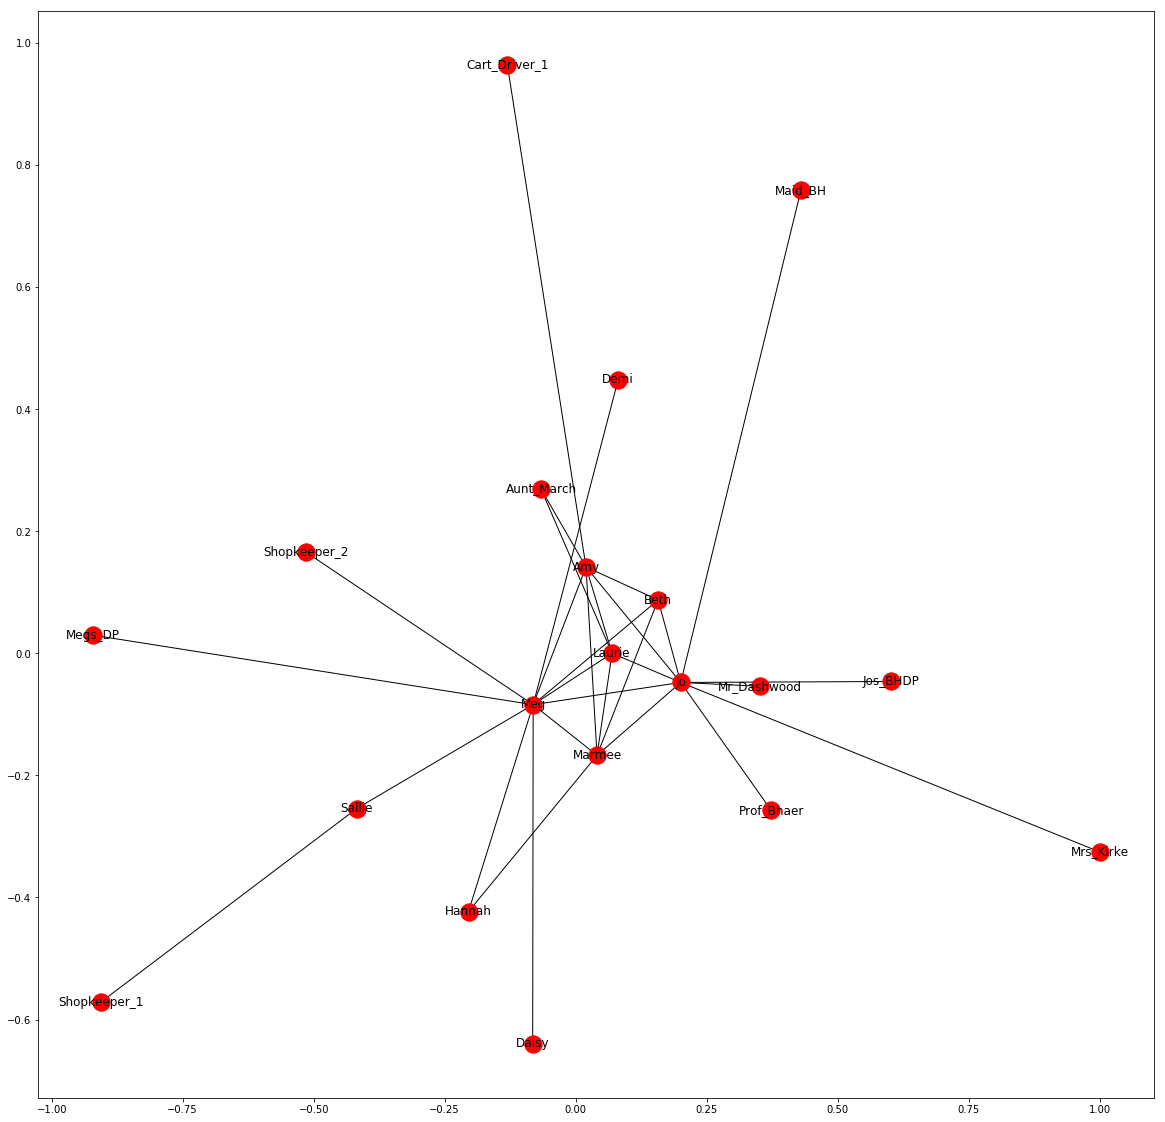

            Nodes  Degree       ECF       NCF
0              Jo   170.0  0.813814  0.254489
1     Mr_Dashwood    40.0  0.123123  0.030481
2      Prof_Bhaer    14.0  0.045045  0.010668
3         Maid_BH     1.0  0.006006  0.000762
4       Mrs_Kirke     1.0  0.006006  0.000762
5             Amy    99.0  0.729730  0.147756
6      Aunt_March    33.0  0.216216  0.026337
7   Cart_Driver_1     1.0  0.003003  0.000446
8          Laurie   117.0  0.648649  0.174621
9          Sallie    12.0  0.042042  0.004762
10   Shopkeeper_1     2.0  0.006006  0.000108
11            Meg    88.0  0.705706  0.132926
12   Shopkeeper_2     3.0  0.015015  0.001163
13          Daisy     3.0  0.015015  0.001163
14           Demi     3.0  0.015015  0.001163
15           Beth    26.0  0.282282  0.038570
16         Marmee    40.0  0.645646  0.059699
17       Jos_BHDP     6.0  0.021021  0.004572
18        Megs_DP     1.0  0.009009  0.000388
19         Hannah     6.0  0.051051  0.003165
      Degree       ECF       NCF
0

In [3]:
lw_1 = nx.read_weighted_edgelist('lw_m_1.txt', delimiter=',')
print(nx.info(lw_1))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_1)
plt.show()

#Weighted Centralities
w_deg = lw_1.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_1)  #ECF
w_ecf = weighted_ECF(lw_1, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_1) #NCF
w_ncf = weighted_cness(lw_1,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [4]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.664,0.497,0.676
1,0.156,0.075,0.081
2,0.055,0.028,0.028
3,0.004,0.004,0.002
4,0.004,0.004,0.002
5,0.387,0.446,0.393
6,0.129,0.132,0.070
7,0.004,0.002,0.001
8,0.457,0.396,0.464
9,0.047,0.026,0.013


Text(0, 0.5, 'Values')

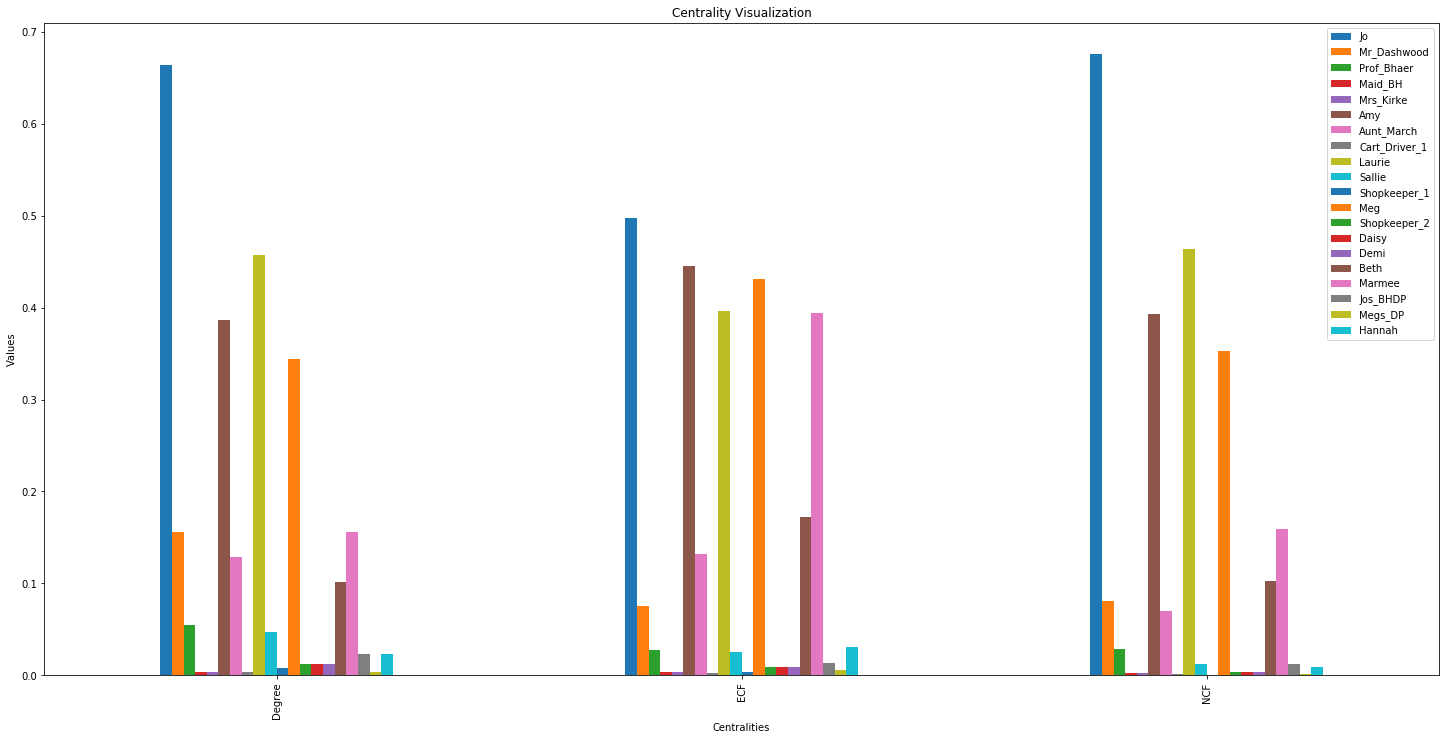

In [4]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),
    "Maid_BH":list(df_2.loc[3]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Cart_Driver_1":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Shopkeeper_1":list(df_2.loc[10]),
    "Meg":list(df_2.loc[11]),
    "Shopkeeper_2":list(df_2.loc[12]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Jos_BHDP":list(df_2.loc[17]),
    "Megs_DP":list(df_2.loc[18]),
    "Hannah":list(df_2.loc[19])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

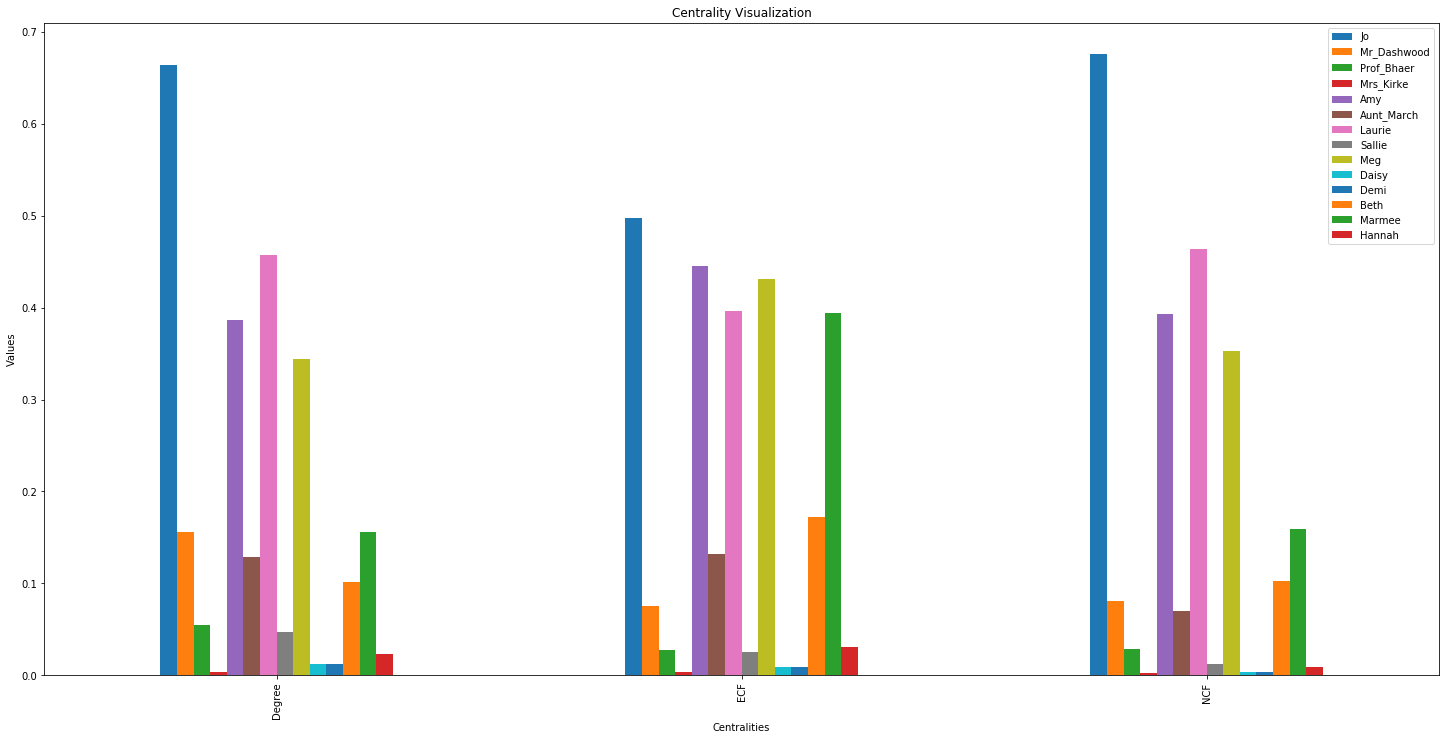

In [5]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),   
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Meg":list(df_2.loc[11]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Hannah":list(df_2.loc[19])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

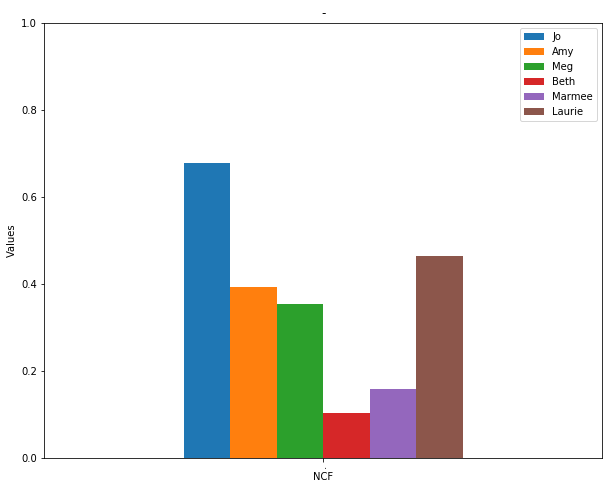

In [6]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[5][2],
    "Meg":df_2.loc[11][2],
    "Beth":df_2.loc[15][2],
    "Marmee":df_2.loc[16][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_2

Name: 
Type: Graph
Number of nodes: 29
Number of edges: 51
Average degree:   3.5172


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


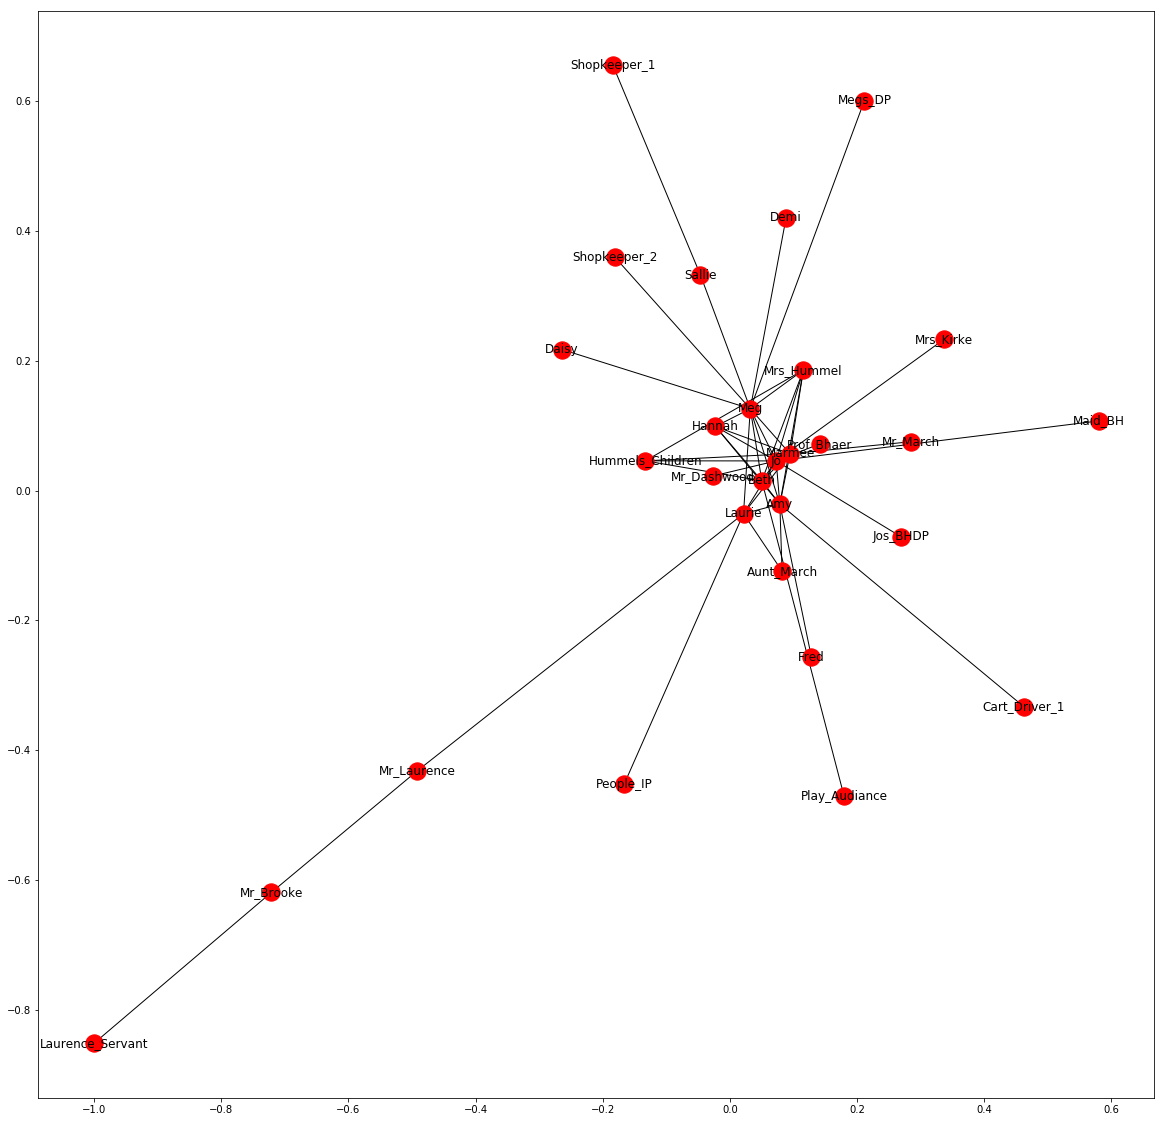

               Nodes  Degree       ECF       NCF
0                 Jo   397.0  0.902036  0.251581
1        Mr_Dashwood    40.0  0.054707  0.012755
2         Prof_Bhaer    72.0  0.095420  0.022959
3            Maid_BH     1.0  0.005089  0.000319
4          Mrs_Kirke     3.0  0.007634  0.000957
5                Amy   265.0  0.786260  0.167288
6         Aunt_March    33.0  0.136132  0.009214
7      Cart_Driver_1     1.0  0.001272  0.000214
8             Laurie   154.0  0.571247  0.095970
9             Sallie    12.0  0.017812  0.001768
10      Shopkeeper_1     2.0  0.002545  0.000019
11               Meg   182.0  0.762087  0.115481
12      Shopkeeper_2     3.0  0.006361  0.000437
13             Daisy     3.0  0.006361  0.000437
14              Demi     3.0  0.006361  0.000437
15              Beth   128.0  0.557252  0.080389
16            Marmee   183.0  0.758270  0.115524
17          Jos_BHDP     6.0  0.011450  0.001913
18           Megs_DP     1.0  0.003817  0.000146
19            Hannah

In [5]:
lw_2 = nx.read_weighted_edgelist('lw_m_2.txt', delimiter=',')
print(nx.info(lw_2))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_2)
plt.show()

#Weighted Centralities
w_deg = lw_2.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_2)  #ECF
w_ecf = weighted_ECF(lw_2, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_2) #NCF
w_ncf = weighted_cness(lw_2,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [6]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.677,0.461,0.685
1,0.068,0.028,0.035
2,0.123,0.049,0.062
3,0.002,0.003,0.001
4,0.005,0.004,0.003
5,0.452,0.402,0.455
6,0.056,0.070,0.025
7,0.002,0.001,0.001
8,0.262,0.292,0.261
9,0.020,0.009,0.005


Text(0, 0.5, 'Values')

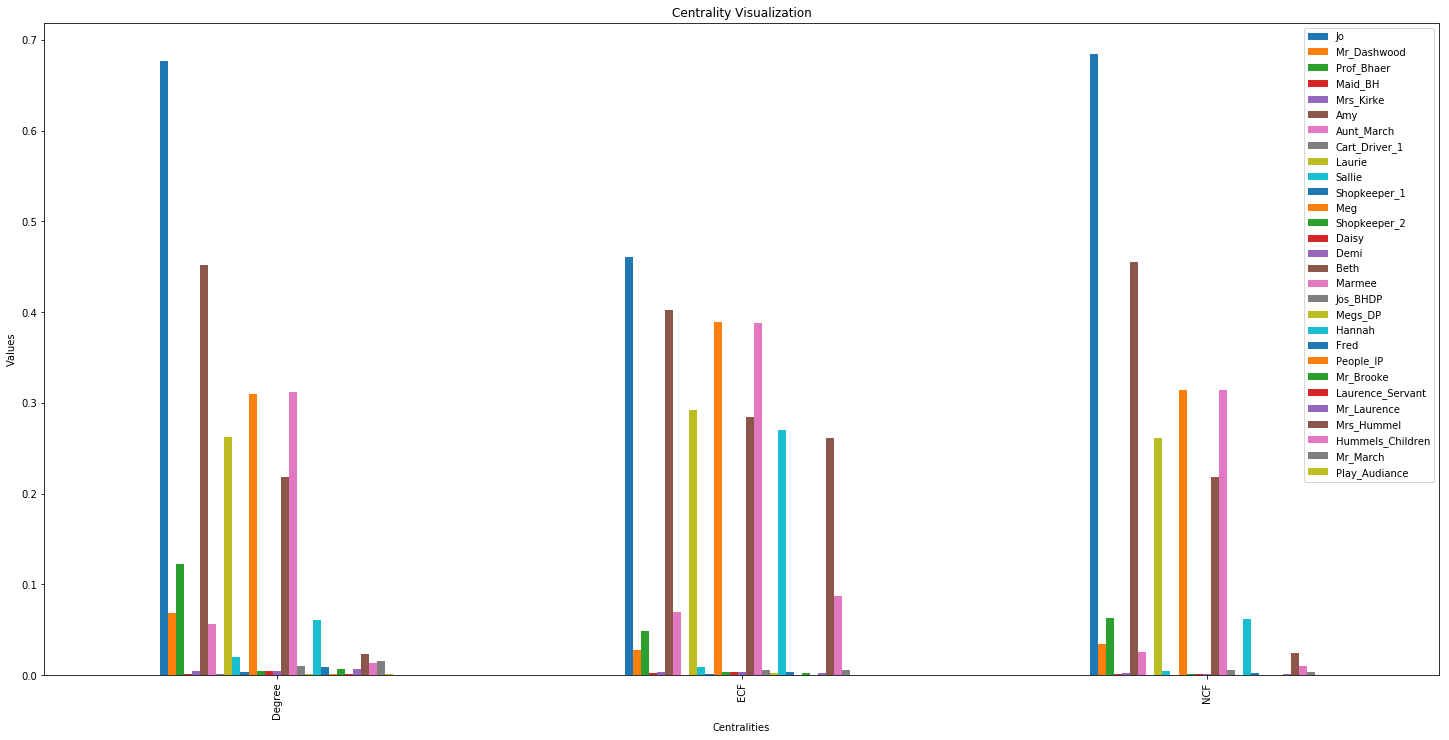

In [8]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),
    "Maid_BH":list(df_2.loc[3]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Cart_Driver_1":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Shopkeeper_1":list(df_2.loc[10]),
    "Meg":list(df_2.loc[11]),
    "Shopkeeper_2":list(df_2.loc[12]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Jos_BHDP":list(df_2.loc[17]),
    "Megs_DP":list(df_2.loc[18]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "People_IP":list(df_2.loc[21]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Laurence_Servant":list(df_2.loc[23]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mrs_Hummel":list(df_2.loc[25]),
    "Hummels_Children":list(df_2.loc[26]),
    "Mr_March":list(df_2.loc[27]),
    "Play_Audiance":list(df_2.loc[28])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

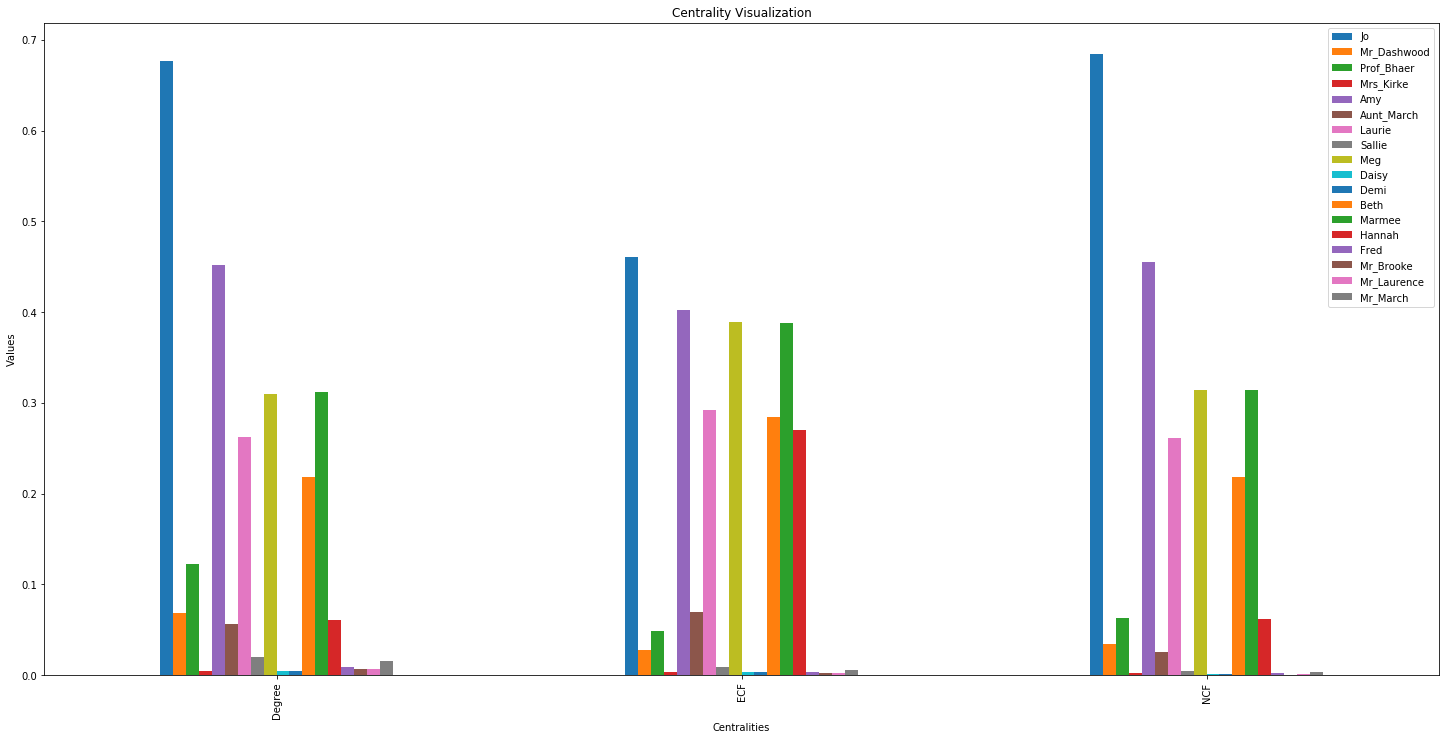

In [9]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),  
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Meg":list(df_2.loc[11]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mr_March":list(df_2.loc[27])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

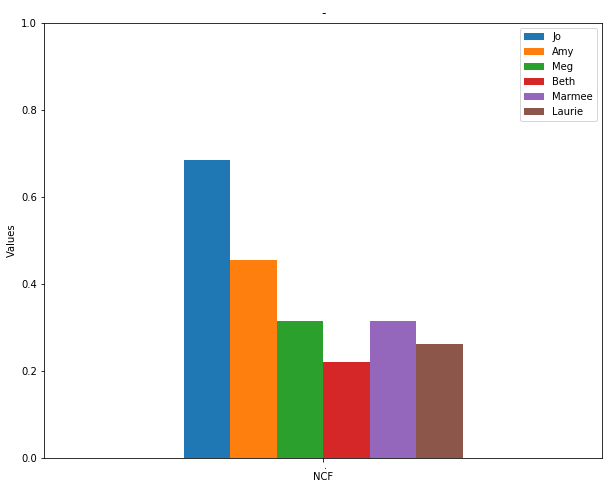

In [10]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[5][2],
    "Meg":df_2.loc[11][2],
    "Beth":df_2.loc[15][2],
    "Marmee":df_2.loc[16][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_3

Name: 
Type: Graph
Number of nodes: 35
Number of edges: 66
Average degree:   3.7714


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


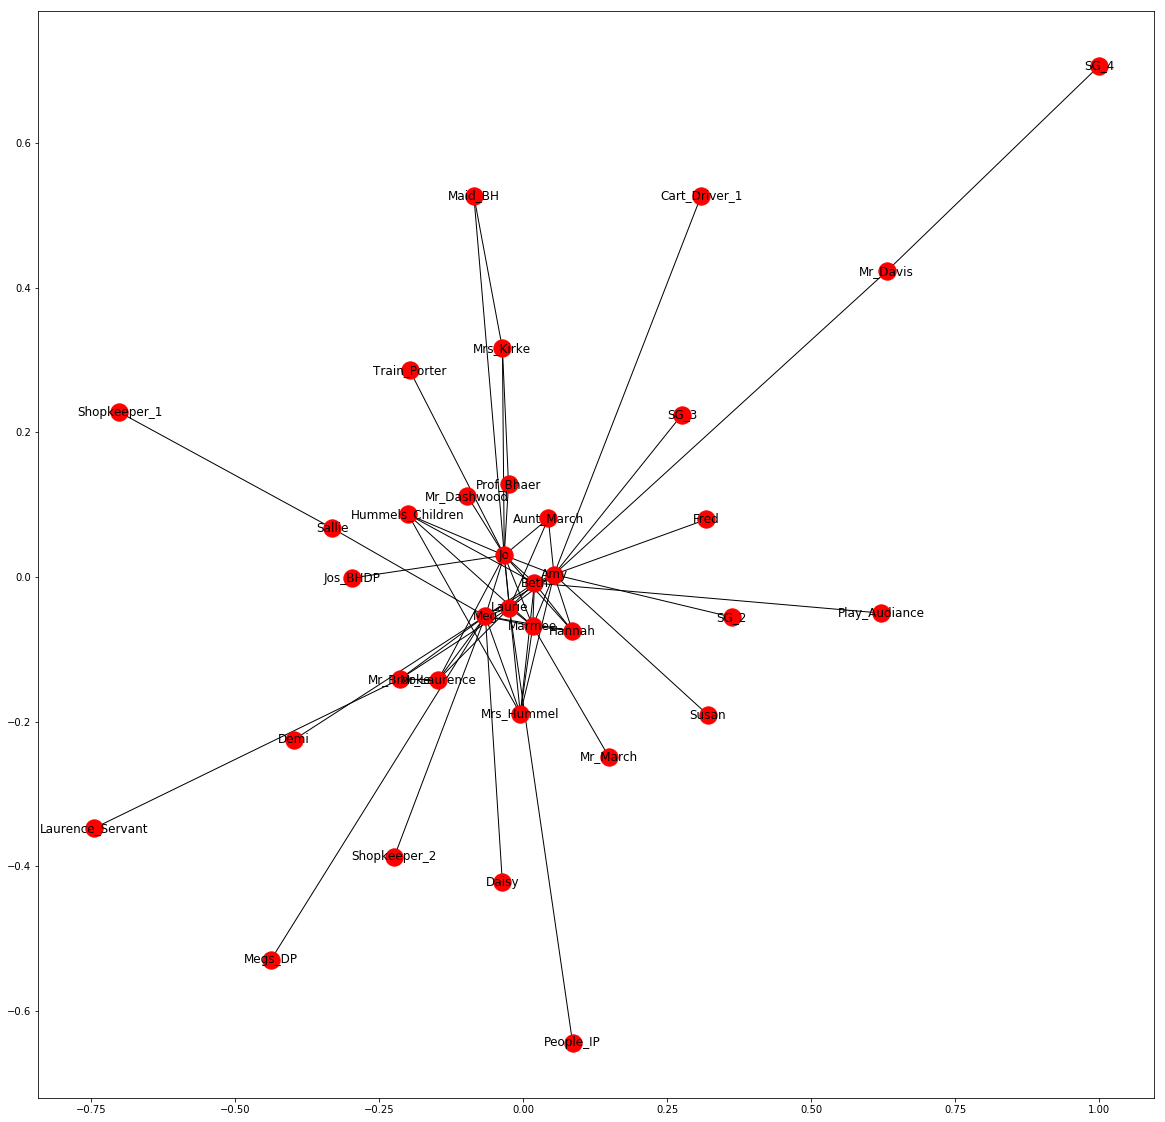

               Nodes  Degree       ECF           NCF
0                 Jo   577.0  0.932409  2.500000e-01
1        Mr_Dashwood    40.0  0.038128  8.605438e-03
2         Prof_Bhaer    81.0  0.076256  1.779096e-02
3            Maid_BH     4.0  0.009532  8.785657e-04
4          Mrs_Kirke    15.0  0.079723  3.294621e-03
5                Amy   396.0  0.811092  1.687522e-01
6         Aunt_March    83.0  0.323224  2.957350e-02
7      Cart_Driver_1     1.0  0.001733  1.483049e-04
8             Laurie   266.0  0.784229  1.136534e-01
9             Sallie    12.0  0.012132  1.302079e-03
10      Shopkeeper_1     2.0  0.001733  9.010930e-06
11               Meg   289.0  0.771231  1.240231e-01
12      Shopkeeper_2     3.0  0.004333  3.232671e-04
13             Daisy     3.0  0.004333  3.232671e-04
14              Demi     3.0  0.004333  3.232671e-04
15              Beth   184.0  0.730503  7.827194e-02
16            Marmee   205.0  0.737435  8.720515e-02
17          Jos_BHDP     6.0  0.008666  1.2908

In [7]:
lw_3 = nx.read_weighted_edgelist('lw_m_3.txt', delimiter=',')
print(nx.info(lw_3))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_3)
plt.show()

#Weighted Centralities
w_deg = lw_3.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_3)  #ECF
w_ecf = weighted_ECF(lw_3, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_3) #NCF
w_ncf = weighted_cness(lw_3,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [8]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.672,0.441,0.681
1,0.047,0.018,0.023
2,0.094,0.036,0.048
3,0.005,0.005,0.002
4,0.017,0.038,0.009
5,0.461,0.383,0.460
6,0.097,0.153,0.081
7,0.001,0.001,0.000
8,0.310,0.371,0.310
9,0.014,0.006,0.004


Text(0, 0.5, 'Values')

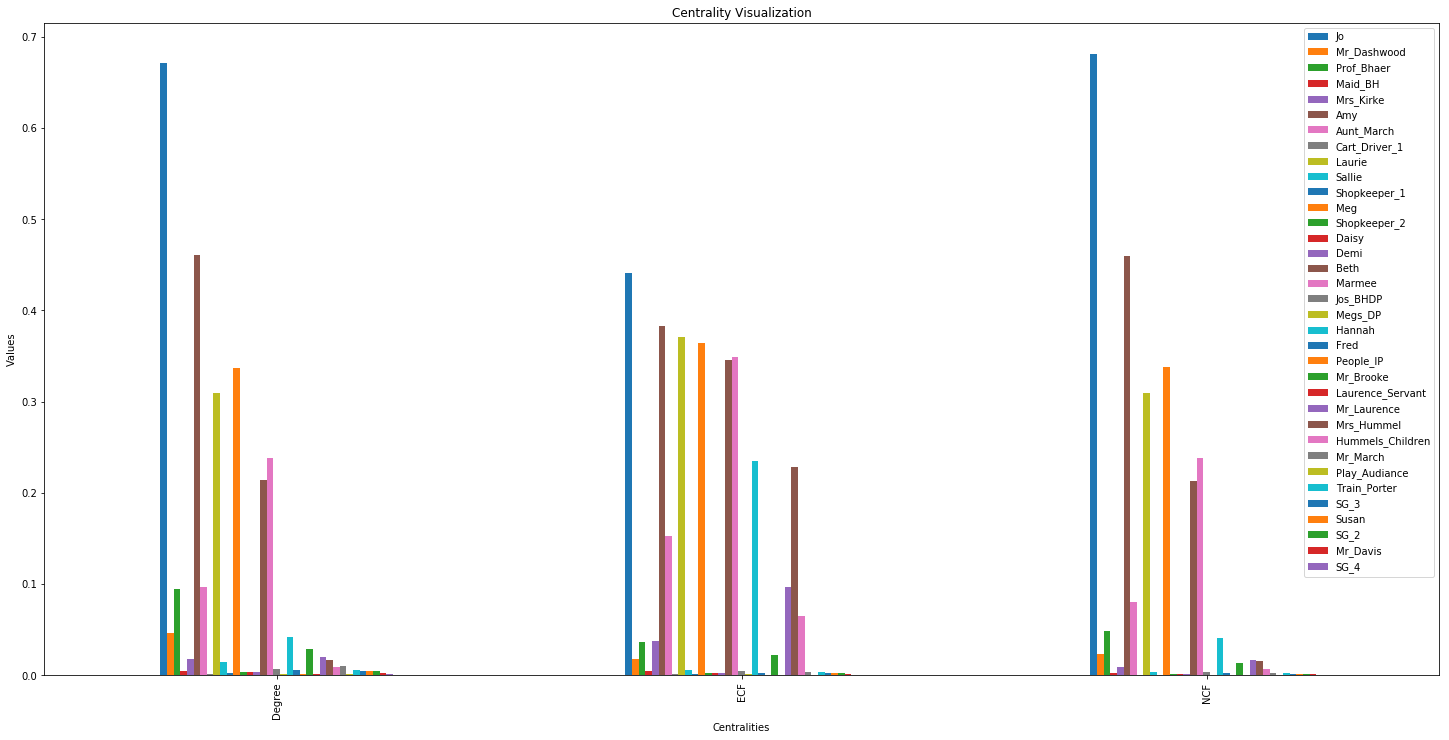

In [12]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),
    "Maid_BH":list(df_2.loc[3]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Cart_Driver_1":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Shopkeeper_1":list(df_2.loc[10]),
    "Meg":list(df_2.loc[11]),
    "Shopkeeper_2":list(df_2.loc[12]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Jos_BHDP":list(df_2.loc[17]),
    "Megs_DP":list(df_2.loc[18]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "People_IP":list(df_2.loc[21]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Laurence_Servant":list(df_2.loc[23]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mrs_Hummel":list(df_2.loc[25]),
    "Hummels_Children":list(df_2.loc[26]),
    "Mr_March":list(df_2.loc[27]),
    "Play_Audiance":list(df_2.loc[28]),
    "Train_Porter":list(df_2.loc[29]),
    "SG_3":list(df_2.loc[30]),
    "Susan":list(df_2.loc[31]),
    "SG_2":list(df_2.loc[32]),
    "Mr_Davis":list(df_2.loc[33]),
    "SG_4":list(df_2.loc[34])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

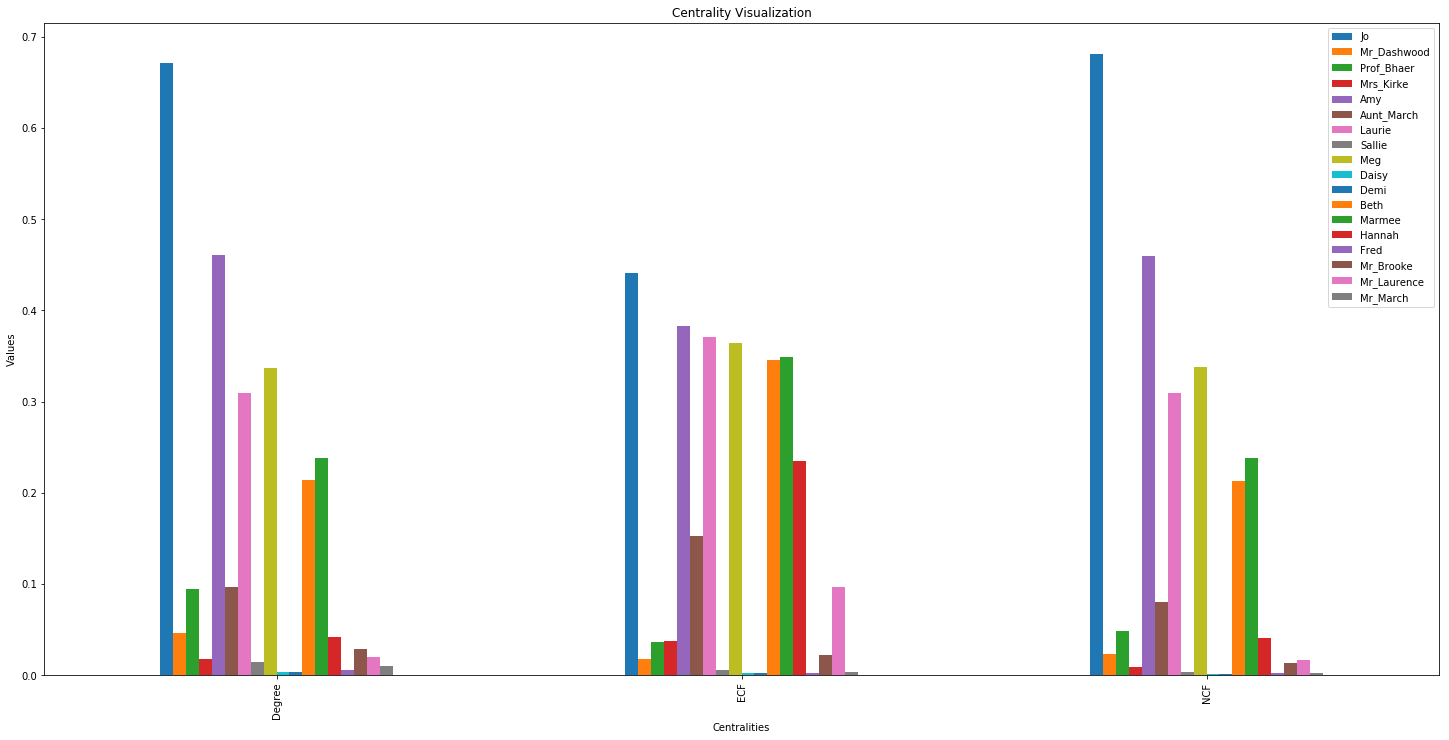

In [13]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Meg":list(df_2.loc[11]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mr_March":list(df_2.loc[27])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

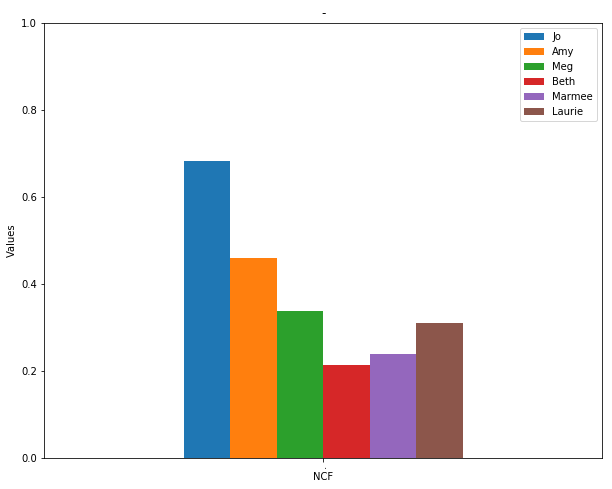

In [14]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[5][2],
    "Meg":df_2.loc[11][2],
    "Beth":df_2.loc[15][2],
    "Marmee":df_2.loc[16][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_4

Name: 
Type: Graph
Number of nodes: 35
Number of edges: 68
Average degree:   3.8857


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


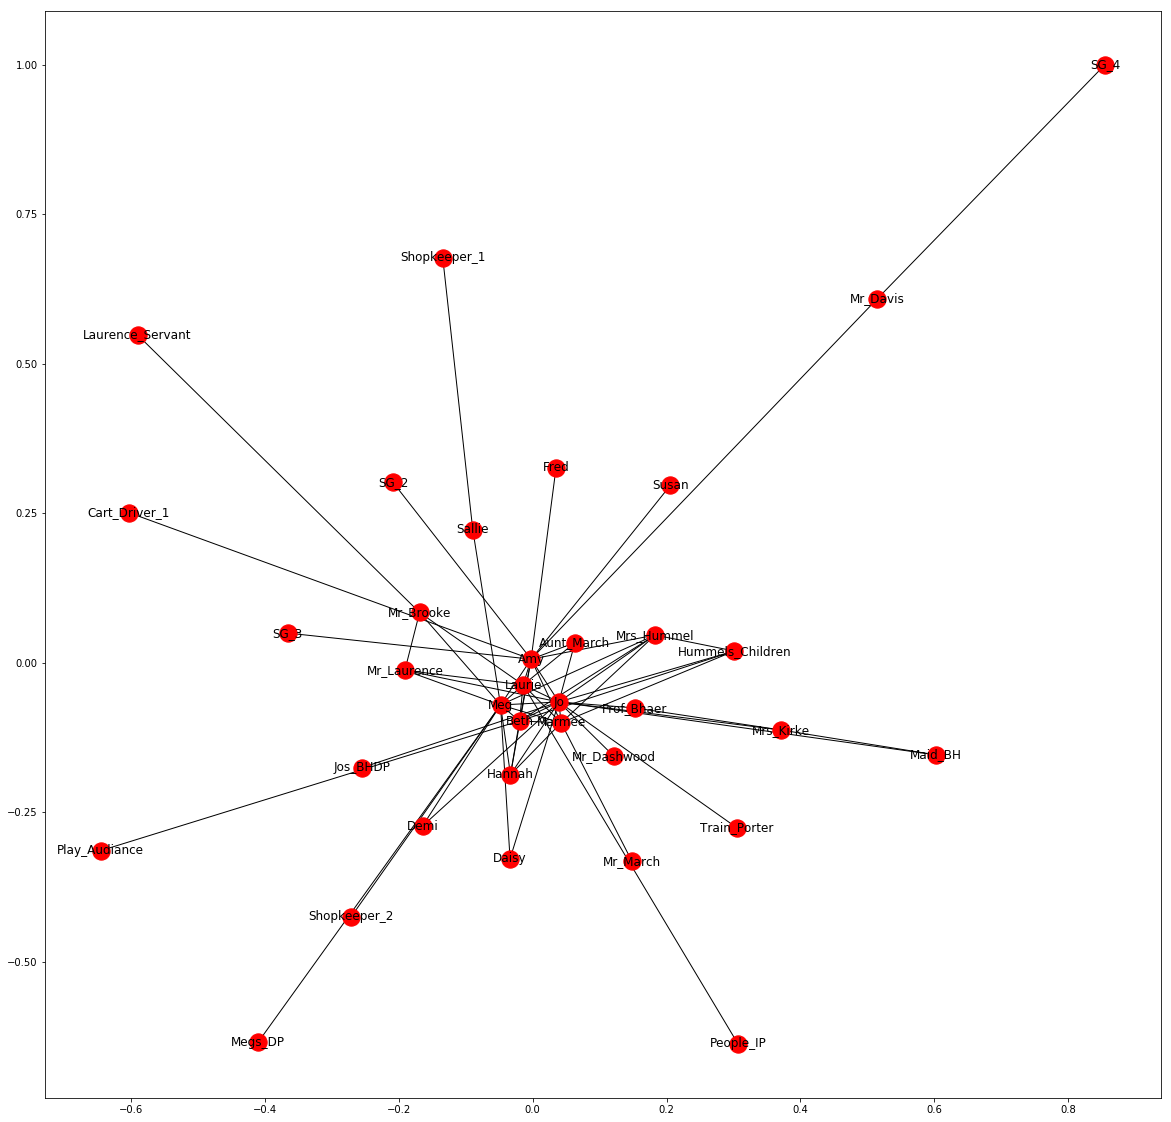

               Nodes  Degree       ECF           NCF
0                 Jo   746.0  0.946043  2.683453e-01
1        Mr_Dashwood    40.0  0.031655  7.680762e-03
2         Prof_Bhaer    81.0  0.063309  1.580508e-02
3            Maid_BH     4.0  0.007914  7.804979e-04
4          Mrs_Kirke    15.0  0.066187  2.926867e-03
5                Amy   495.0  0.832374  1.756237e-01
6         Aunt_March    83.0  0.336691  2.502329e-02
7      Cart_Driver_1     1.0  0.001439  1.278402e-04
8             Laurie   309.0  0.807914  1.098716e-01
9             Sallie    12.0  0.010072  1.105533e-03
10      Shopkeeper_1     2.0  0.001439  6.210859e-06
11               Meg   356.0  0.810072  1.270441e-01
12      Shopkeeper_2     3.0  0.003597  2.748305e-04
13             Daisy     9.0  0.100719  2.261529e-03
14              Demi     9.0  0.100719  2.261529e-03
15              Beth   204.0  0.765468  7.227266e-02
16            Marmee   258.0  0.771223  9.140365e-02
17          Jos_BHDP     6.0  0.007194  1.1521

In [9]:
lw_4 = nx.read_weighted_edgelist('lw_m_4.txt', delimiter=',')
print(nx.info(lw_4))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_4)
plt.show()

#Weighted Centralities
w_deg = lw_4.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_4)  #ECF
w_ecf = weighted_ECF(lw_4, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_4) #NCF
w_ncf = weighted_cness(lw_4,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [10]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.695,0.429,0.703
1,0.037,0.014,0.020
2,0.076,0.029,0.041
3,0.004,0.004,0.002
4,0.014,0.030,0.008
5,0.461,0.378,0.460
6,0.077,0.153,0.066
7,0.001,0.001,0.000
8,0.288,0.367,0.288
9,0.011,0.005,0.003


Text(0, 0.5, 'Values')

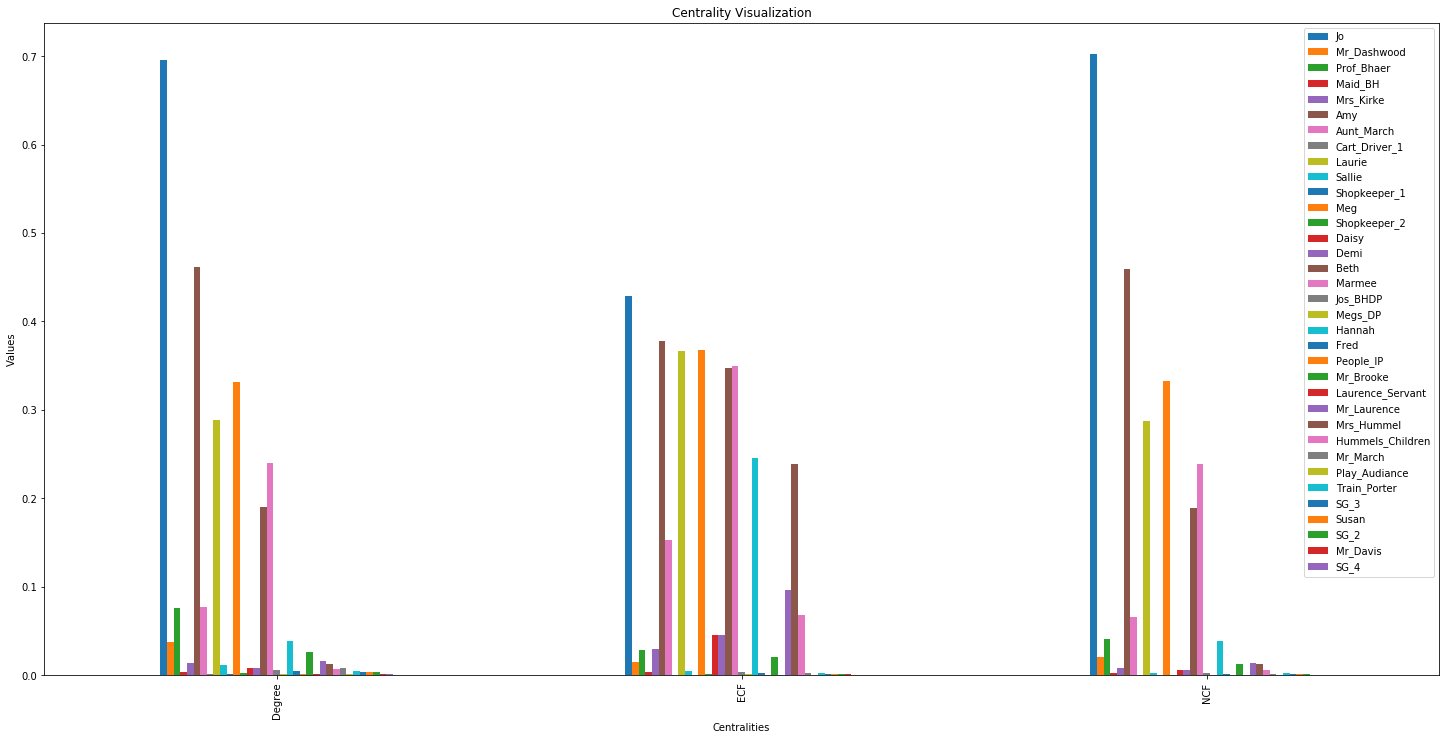

In [16]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),
    "Maid_BH":list(df_2.loc[3]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Cart_Driver_1":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Shopkeeper_1":list(df_2.loc[10]),
    "Meg":list(df_2.loc[11]),
    "Shopkeeper_2":list(df_2.loc[12]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Jos_BHDP":list(df_2.loc[17]),
    "Megs_DP":list(df_2.loc[18]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "People_IP":list(df_2.loc[21]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Laurence_Servant":list(df_2.loc[23]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mrs_Hummel":list(df_2.loc[25]),
    "Hummels_Children":list(df_2.loc[26]),
    "Mr_March":list(df_2.loc[27]),
    "Play_Audiance":list(df_2.loc[28]),
    "Train_Porter":list(df_2.loc[29]),
    "SG_3":list(df_2.loc[30]),
    "Susan":list(df_2.loc[31]),
    "SG_2":list(df_2.loc[32]),
    "Mr_Davis":list(df_2.loc[33]),
    "SG_4":list(df_2.loc[34])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

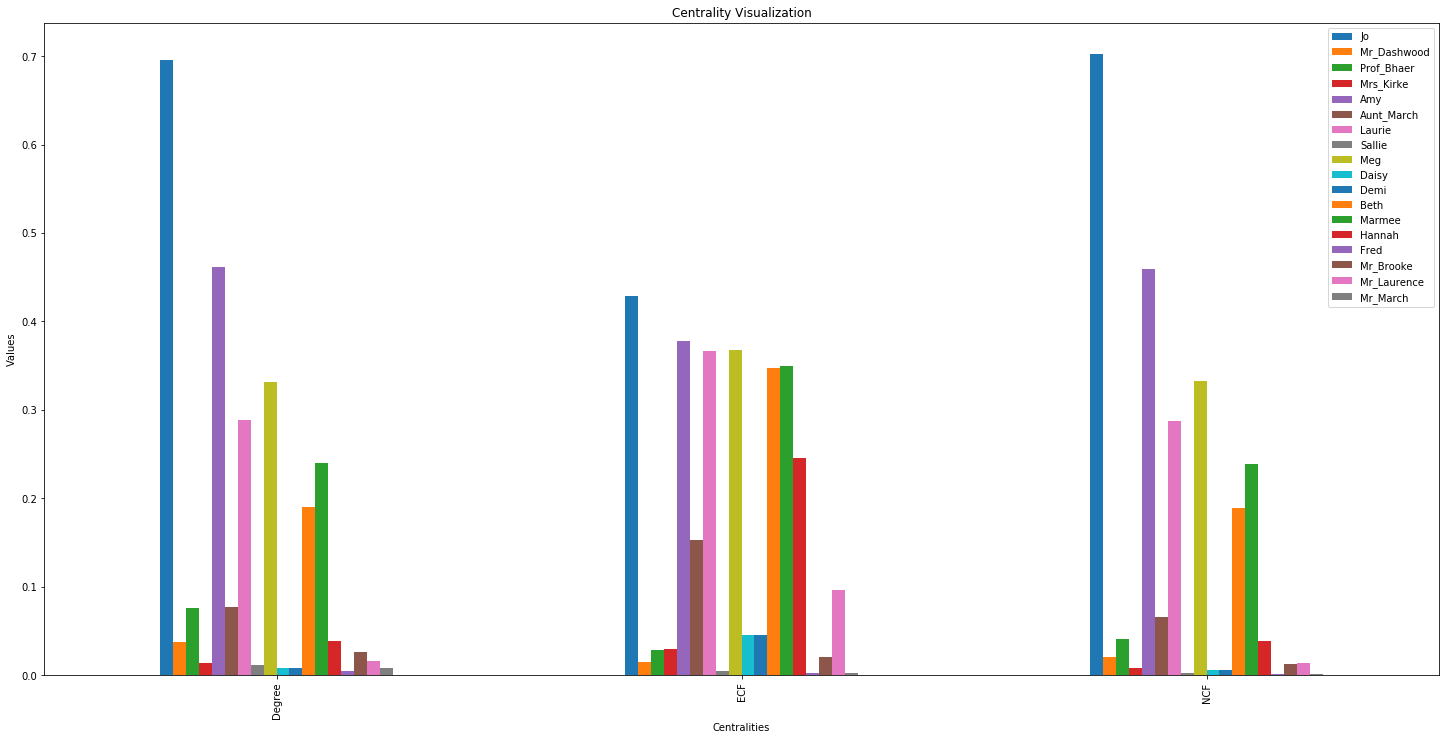

In [17]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Meg":list(df_2.loc[11]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mr_March":list(df_2.loc[27])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

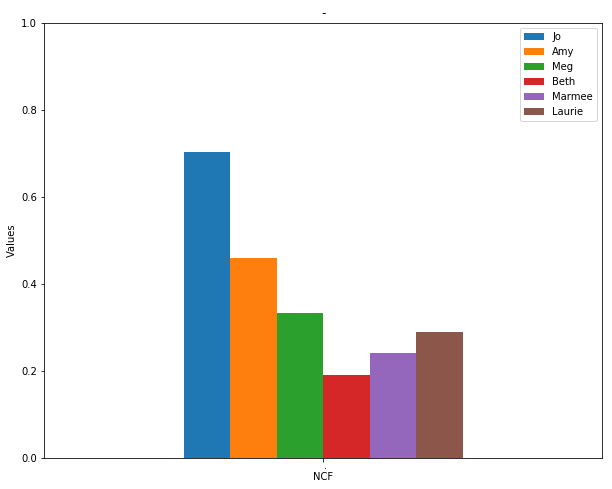

In [18]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[5][2],
    "Meg":df_2.loc[11][2],
    "Beth":df_2.loc[15][2],
    "Marmee":df_2.loc[16][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_5

Name: 
Type: Graph
Number of nodes: 38
Number of edges: 79
Average degree:   4.1579


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


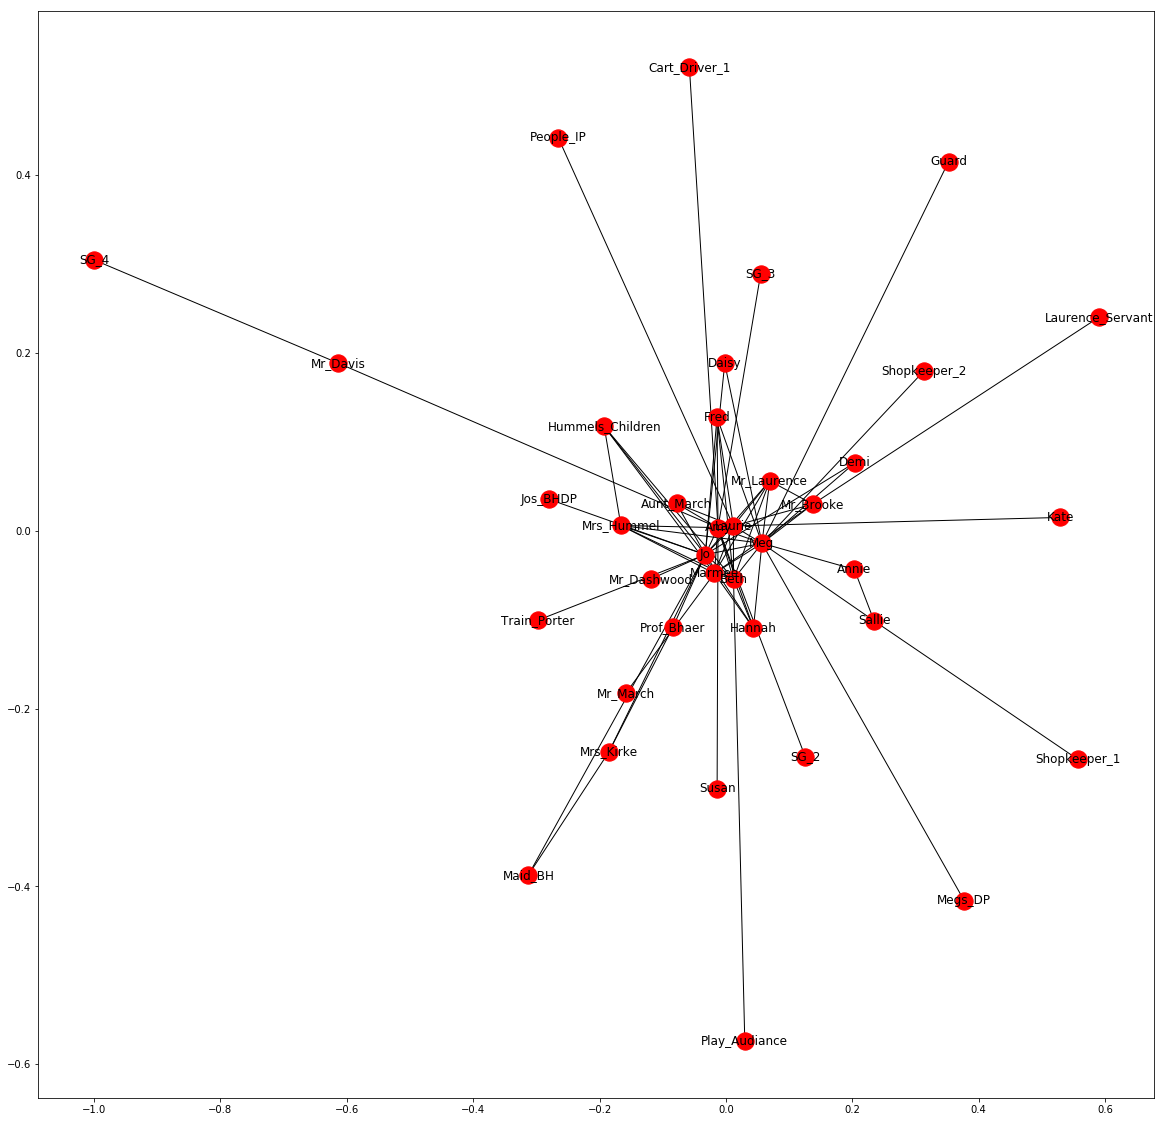

               Nodes  Degree       ECF           NCF
0                 Jo   809.0  0.922527  2.406298e-01
1        Mr_Dashwood    40.0  0.026222  5.717971e-03
2         Prof_Bhaer    81.0  0.052443  1.175150e-02
3            Maid_BH     4.0  0.006555  5.803208e-04
4          Mrs_Kirke    15.0  0.054827  2.176203e-03
5                Amy   593.0  0.816448  1.743818e-01
6         Aunt_March    83.0  0.344458  1.995643e-02
7      Cart_Driver_1     1.0  0.001192  1.051254e-04
8             Laurie   447.0  0.824791  1.316861e-01
9             Sallie    22.0  0.023838  1.871304e-03
10      Shopkeeper_1     2.0  0.001192  7.813377e-06
11               Meg   476.0  0.845054  1.409057e-01
12      Shopkeeper_2     3.0  0.002980  2.525141e-04
13             Daisy     9.0  0.088200  1.831527e-03
14              Demi     9.0  0.088200  1.831527e-03
15              Beth   244.0  0.780095  7.188236e-02
16            Marmee   279.0  0.809297  8.224289e-02
17          Jos_BHDP     6.0  0.005959  8.5769

In [11]:
lw_5 = nx.read_weighted_edgelist('lw_m_5.txt', delimiter=',')
print(nx.info(lw_5))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_5)
plt.show()

#Weighted Centralities
w_deg = lw_5.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_5)  #ECF
w_ecf = weighted_ECF(lw_5, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_5) #NCF
w_ncf = weighted_cness(lw_5,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [12]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.641,0.399,0.647
1,0.032,0.011,0.015
2,0.064,0.023,0.032
3,0.003,0.003,0.002
4,0.012,0.024,0.006
5,0.470,0.353,0.469
6,0.066,0.149,0.054
7,0.001,0.001,0.000
8,0.354,0.357,0.354
9,0.017,0.010,0.005


Text(0, 0.5, 'Values')

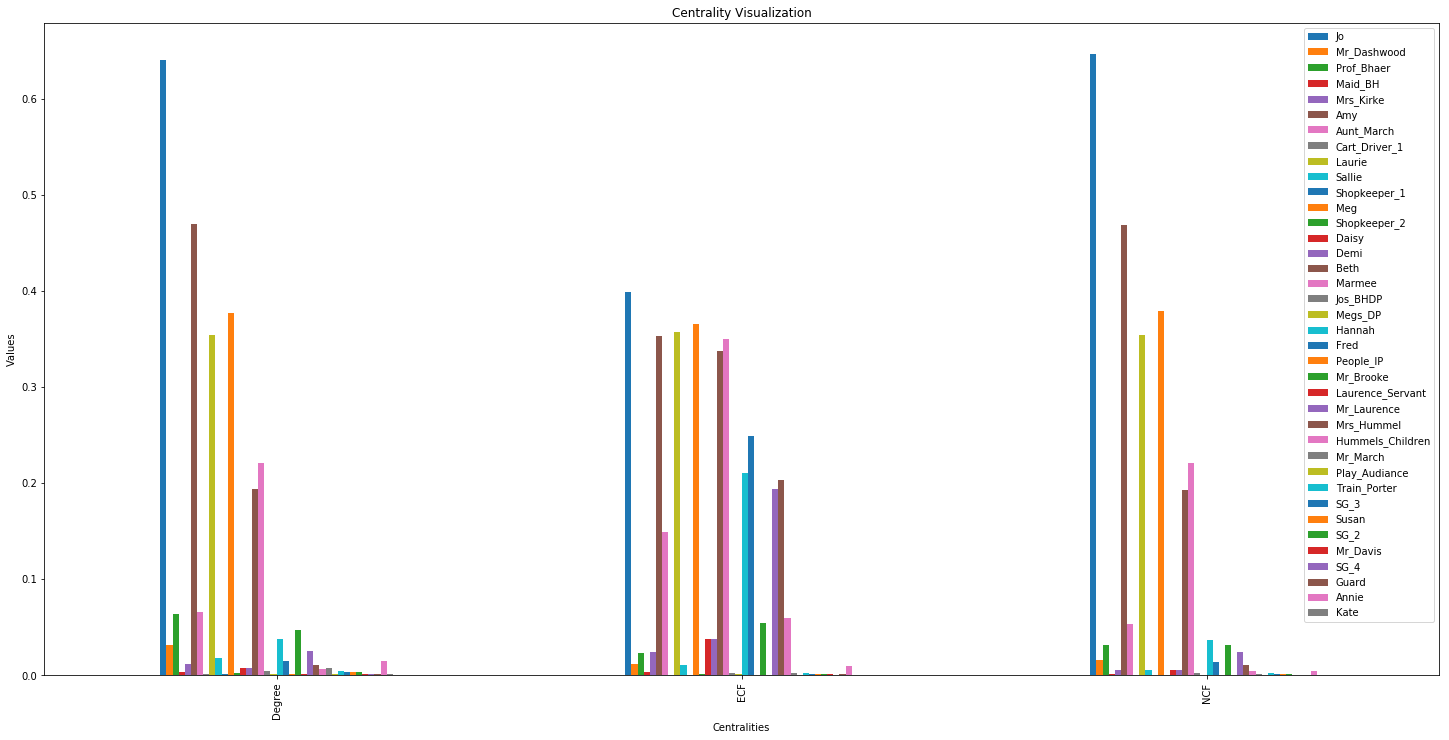

In [20]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),
    "Maid_BH":list(df_2.loc[3]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Cart_Driver_1":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Shopkeeper_1":list(df_2.loc[10]),
    "Meg":list(df_2.loc[11]),
    "Shopkeeper_2":list(df_2.loc[12]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Jos_BHDP":list(df_2.loc[17]),
    "Megs_DP":list(df_2.loc[18]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "People_IP":list(df_2.loc[21]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Laurence_Servant":list(df_2.loc[23]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mrs_Hummel":list(df_2.loc[25]),
    "Hummels_Children":list(df_2.loc[26]),
    "Mr_March":list(df_2.loc[27]),
    "Play_Audiance":list(df_2.loc[28]),
    "Train_Porter":list(df_2.loc[29]),
    "SG_3":list(df_2.loc[30]),
    "Susan":list(df_2.loc[31]),
    "SG_2":list(df_2.loc[32]),
    "Mr_Davis":list(df_2.loc[33]),
    "SG_4":list(df_2.loc[34]),
    "Guard":list(df_2.loc[35]),
    "Annie":list(df_2.loc[36]),
    "Kate":list(df_2.loc[37])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

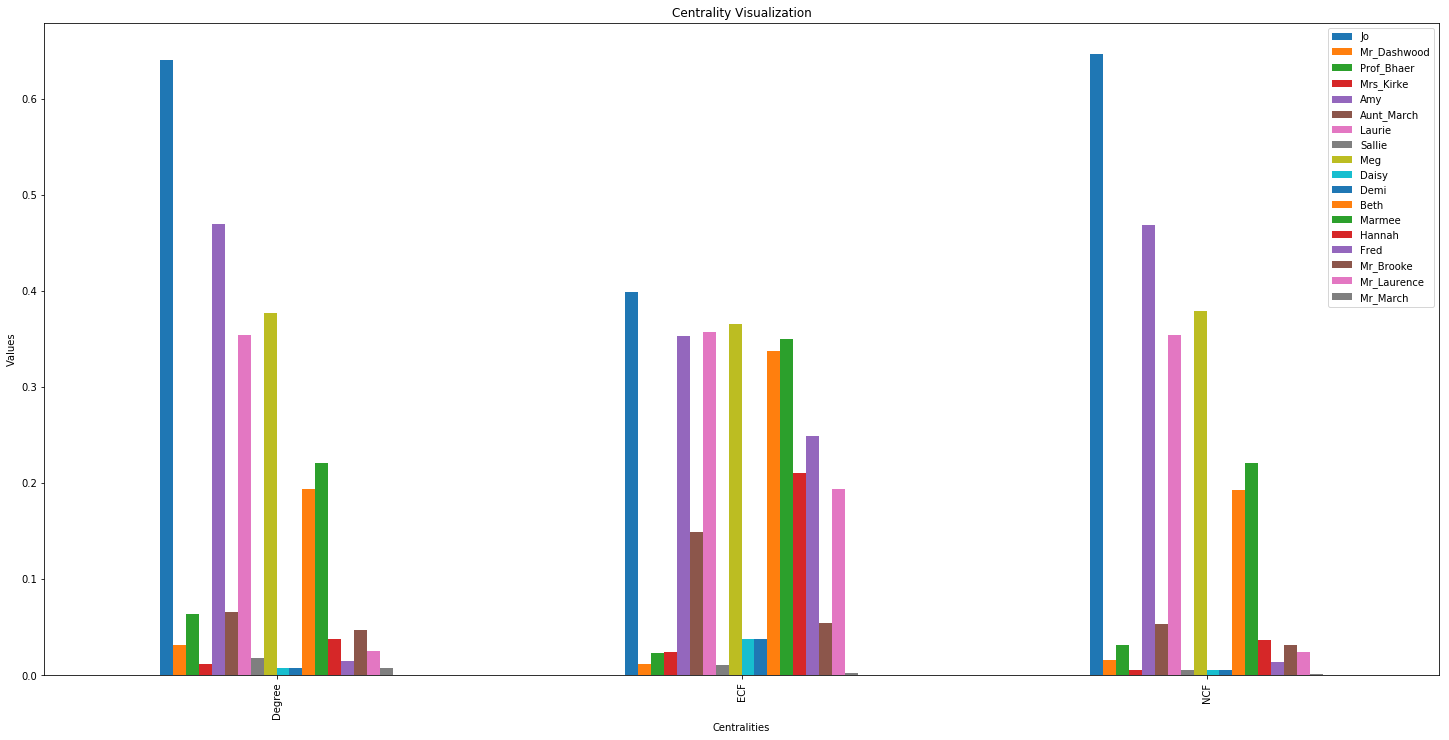

In [21]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Meg":list(df_2.loc[11]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mr_March":list(df_2.loc[27])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

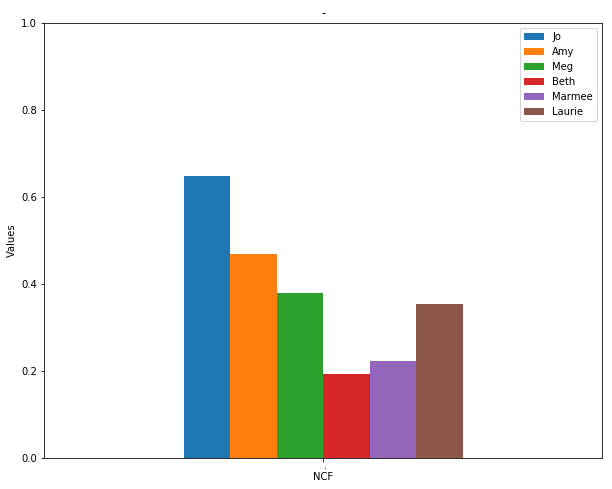

In [22]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[5][2],
    "Meg":df_2.loc[11][2],
    "Beth":df_2.loc[15][2],
    "Marmee":df_2.loc[16][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_6

Name: 
Type: Graph
Number of nodes: 43
Number of edges: 90
Average degree:   4.1860


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


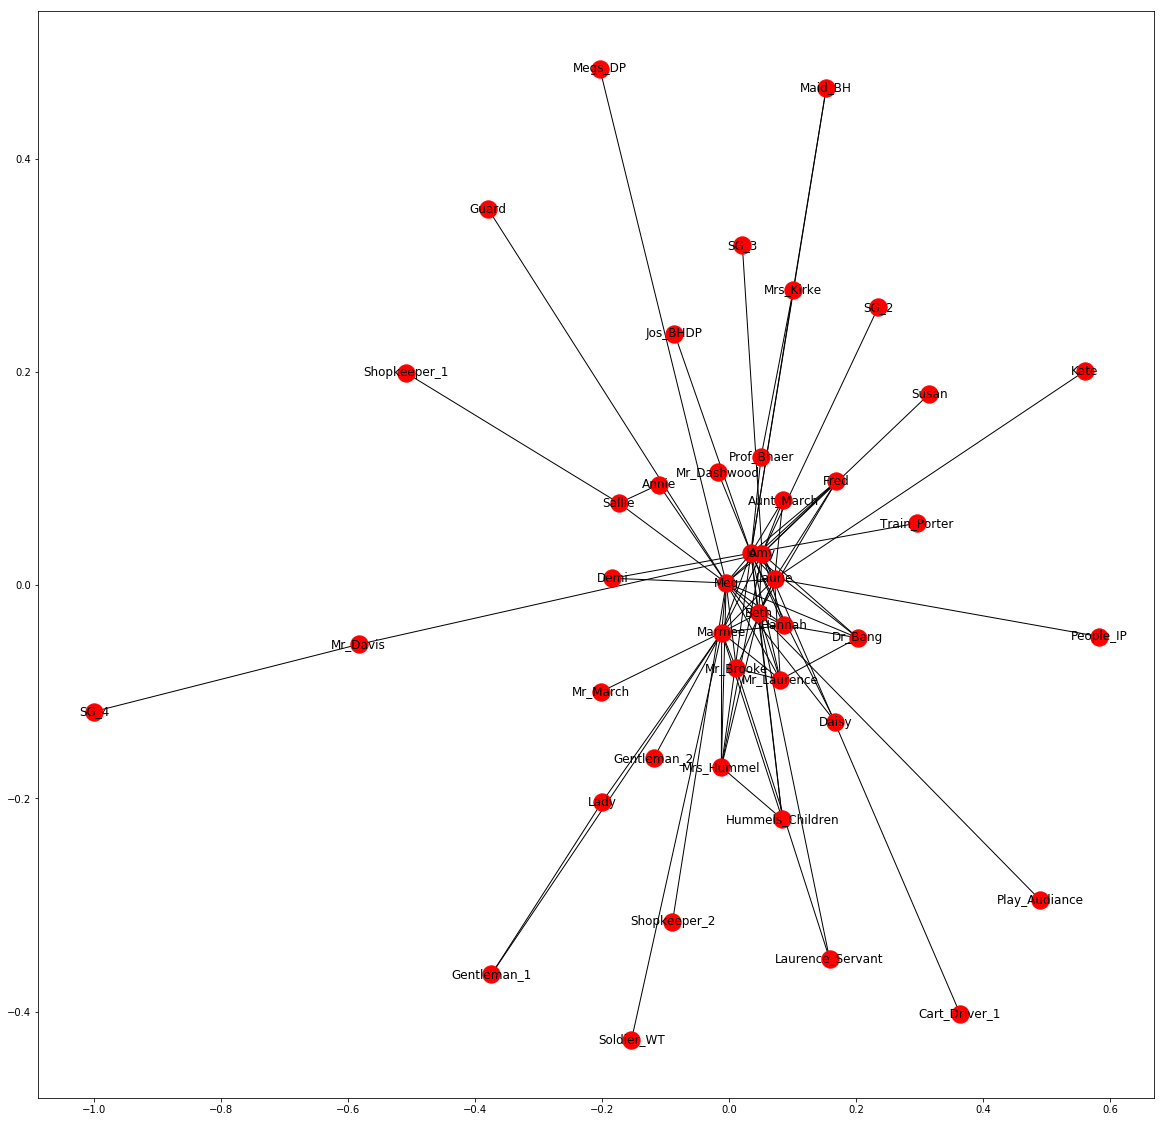

               Nodes  Degree       ECF           NCF
0                 Jo   916.0  0.918296  2.291136e-01
1        Mr_Dashwood    40.0  0.022055  4.582886e-03
2         Prof_Bhaer    81.0  0.044110  9.402454e-03
3            Maid_BH     4.0  0.005514  4.643187e-04
4          Mrs_Kirke    15.0  0.046115  1.741195e-03
5                Amy   720.0  0.818045  1.783707e-01
6         Aunt_March    83.0  0.329825  1.633922e-02
7      Cart_Driver_1     1.0  0.001003  9.032607e-05
8             Laurie   506.0  0.821554  1.253550e-01
9             Sallie    22.0  0.020050  1.495217e-03
10      Shopkeeper_1     2.0  0.001003  5.527603e-06
11               Meg   538.0  0.856642  1.340260e-01
12      Shopkeeper_2     3.0  0.002506  2.020088e-04
13             Daisy     9.0  0.081203  1.470971e-03
14              Demi     9.0  0.081203  1.470971e-03
15              Beth   350.0  0.791479  8.688388e-02
16            Marmee   357.0  0.830576  8.866640e-02
17          Jos_BHDP     6.0  0.005013  6.8743

In [13]:
lw_6 = nx.read_weighted_edgelist('lw_m_6.txt', delimiter=',')
print(nx.info(lw_6))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_6)
plt.show()

#Weighted Centralities
w_deg = lw_6.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_6)  #ECF
w_ecf = weighted_ECF(lw_6, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_6) #NCF
w_ncf = weighted_cness(lw_6,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [14]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.620,0.392,0.625
1,0.027,0.009,0.013
2,0.055,0.019,0.026
3,0.003,0.002,0.001
4,0.010,0.020,0.005
5,0.487,0.349,0.487
6,0.056,0.141,0.045
7,0.001,0.000,0.000
8,0.342,0.351,0.342
9,0.015,0.009,0.004


Text(0, 0.5, 'Values')

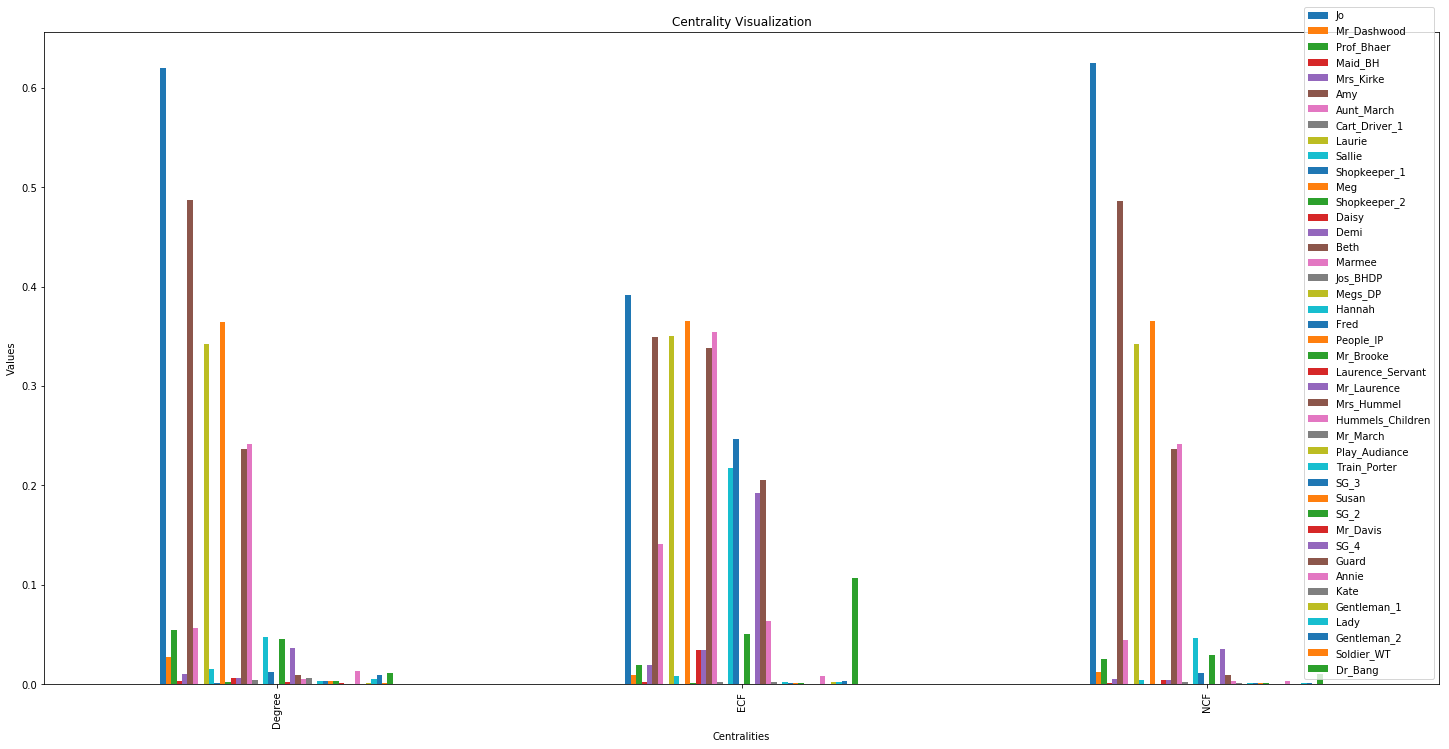

In [24]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),
    "Maid_BH":list(df_2.loc[3]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Cart_Driver_1":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Shopkeeper_1":list(df_2.loc[10]),
    "Meg":list(df_2.loc[11]),
    "Shopkeeper_2":list(df_2.loc[12]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Jos_BHDP":list(df_2.loc[17]),
    "Megs_DP":list(df_2.loc[18]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "People_IP":list(df_2.loc[21]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Laurence_Servant":list(df_2.loc[23]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mrs_Hummel":list(df_2.loc[25]),
    "Hummels_Children":list(df_2.loc[26]),
    "Mr_March":list(df_2.loc[27]),
    "Play_Audiance":list(df_2.loc[28]),
    "Train_Porter":list(df_2.loc[29]),
    "SG_3":list(df_2.loc[30]),
    "Susan":list(df_2.loc[31]),
    "SG_2":list(df_2.loc[32]),
    "Mr_Davis":list(df_2.loc[33]),
    "SG_4":list(df_2.loc[34]),
    "Guard":list(df_2.loc[35]),
    "Annie":list(df_2.loc[36]),
    "Kate":list(df_2.loc[37]),
    "Gentleman_1":list(df_2.loc[38]),
    "Lady":list(df_2.loc[39]),
    "Gentleman_2":list(df_2.loc[40]),
    "Soldier_WT":list(df_2.loc[41]),
    "Dr_Bang":list(df_2.loc[42])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

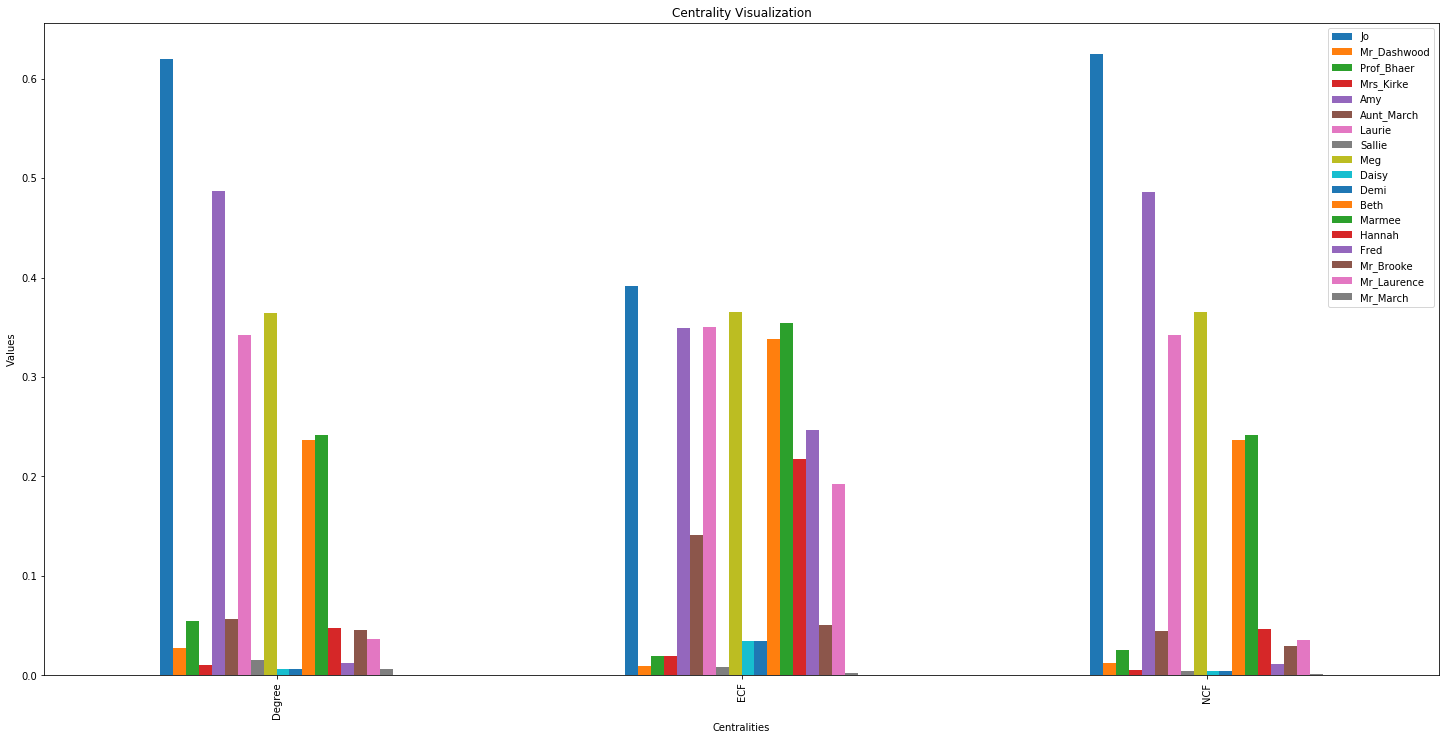

In [25]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Meg":list(df_2.loc[11]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mr_March":list(df_2.loc[27])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

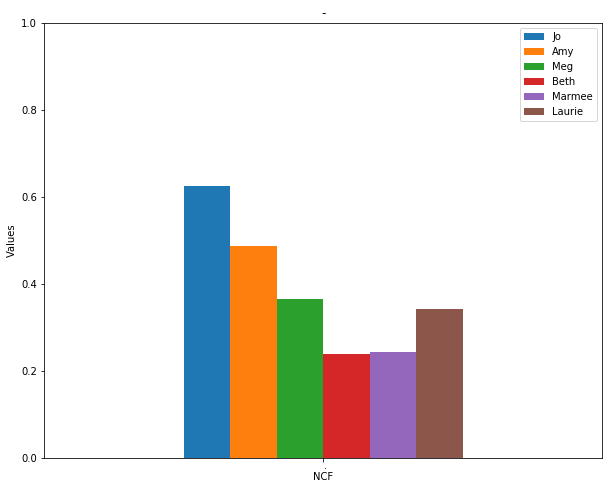

In [26]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[5][2],
    "Meg":df_2.loc[11][2],
    "Beth":df_2.loc[15][2],
    "Marmee":df_2.loc[16][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_7

Name: 
Type: Graph
Number of nodes: 43
Number of edges: 98
Average degree:   4.5581


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


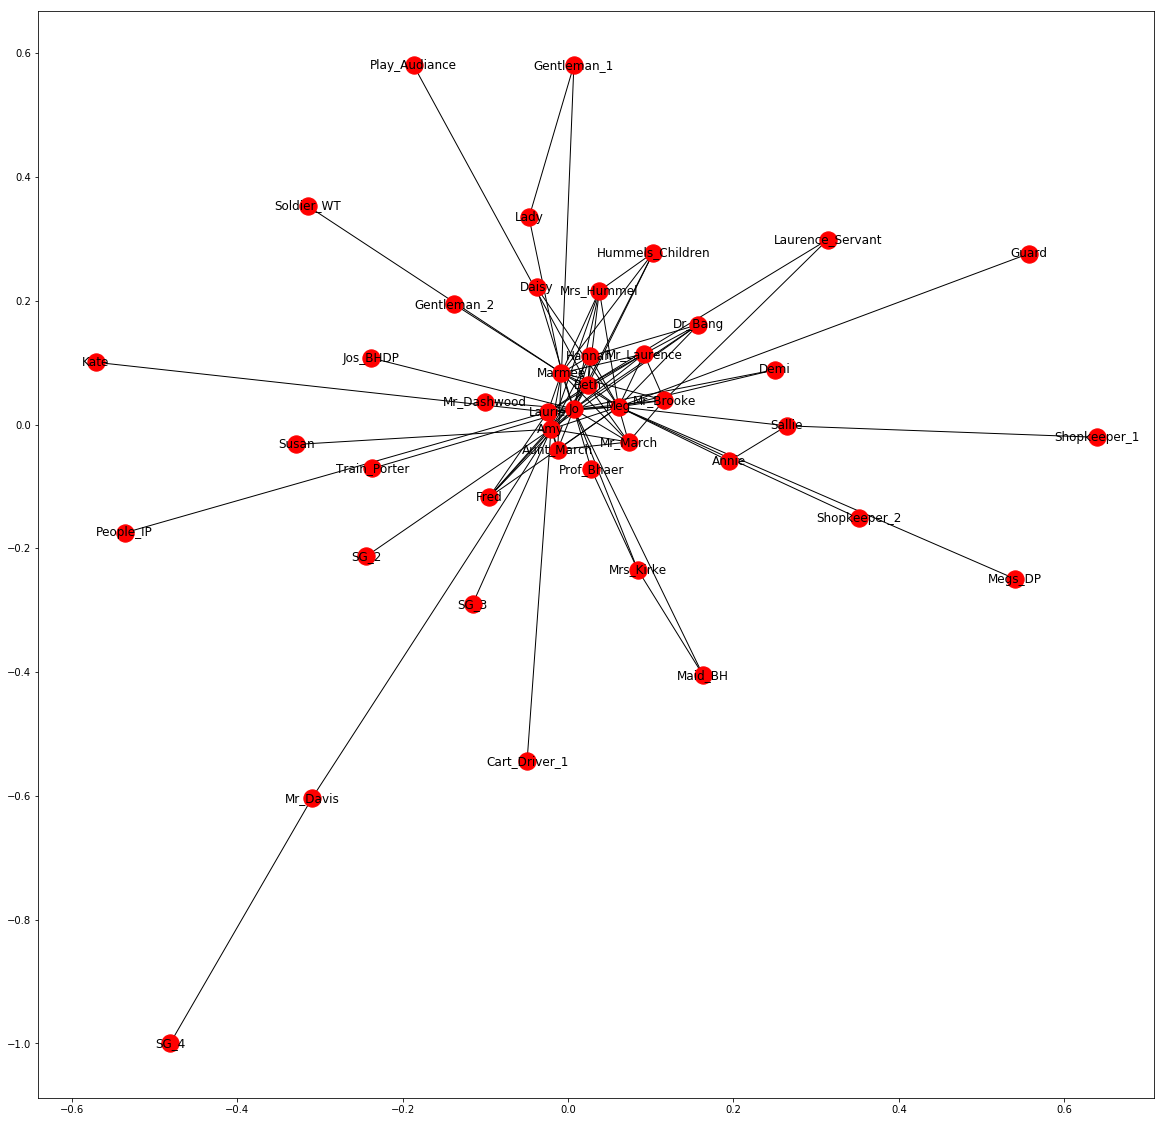

               Nodes  Degree       ECF           NCF
0                 Jo  1111.0  0.921949  2.391297e-01
1        Mr_Dashwood    40.0  0.018974  4.116955e-03
2         Prof_Bhaer    81.0  0.037947  8.427206e-03
3            Maid_BH     4.0  0.004743  4.161583e-04
4          Mrs_Kirke    15.0  0.039672  1.560594e-03
5                Amy   784.0  0.835705  1.673618e-01
6         Aunt_March   132.0  0.623976  2.757690e-02
7      Cart_Driver_1     1.0  0.000862  7.279981e-05
8             Laurie   592.0  0.824925  1.263753e-01
9             Sallie    22.0  0.017249  1.280459e-03
10      Shopkeeper_1     2.0  0.000862  4.090922e-06
11               Meg   623.0  0.916343  1.336301e-01
12      Shopkeeper_2     3.0  0.002156  1.732134e-04
13             Daisy     9.0  0.085813  1.291988e-03
14              Demi     9.0  0.085813  1.291988e-03
15              Beth   399.0  0.791721  8.532361e-02
16            Marmee   400.0  0.890039  8.557465e-02
17          Jos_BHDP     6.0  0.004312  6.1754

In [15]:
lw_7 = nx.read_weighted_edgelist('lw_m_7.txt', delimiter=',')
print(nx.info(lw_7))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_7)
plt.show()

#Weighted Centralities
w_deg = lw_7.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_7)  #ECF
w_ecf = weighted_ECF(lw_7, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_7) #NCF
w_ncf = weighted_cness(lw_7,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [16]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.646,0.366,0.650
1,0.023,0.008,0.011
2,0.047,0.015,0.023
3,0.002,0.002,0.001
4,0.009,0.016,0.004
5,0.456,0.332,0.455
6,0.077,0.248,0.075
7,0.001,0.000,0.000
8,0.344,0.328,0.344
9,0.013,0.007,0.003


Text(0, 0.5, 'Values')

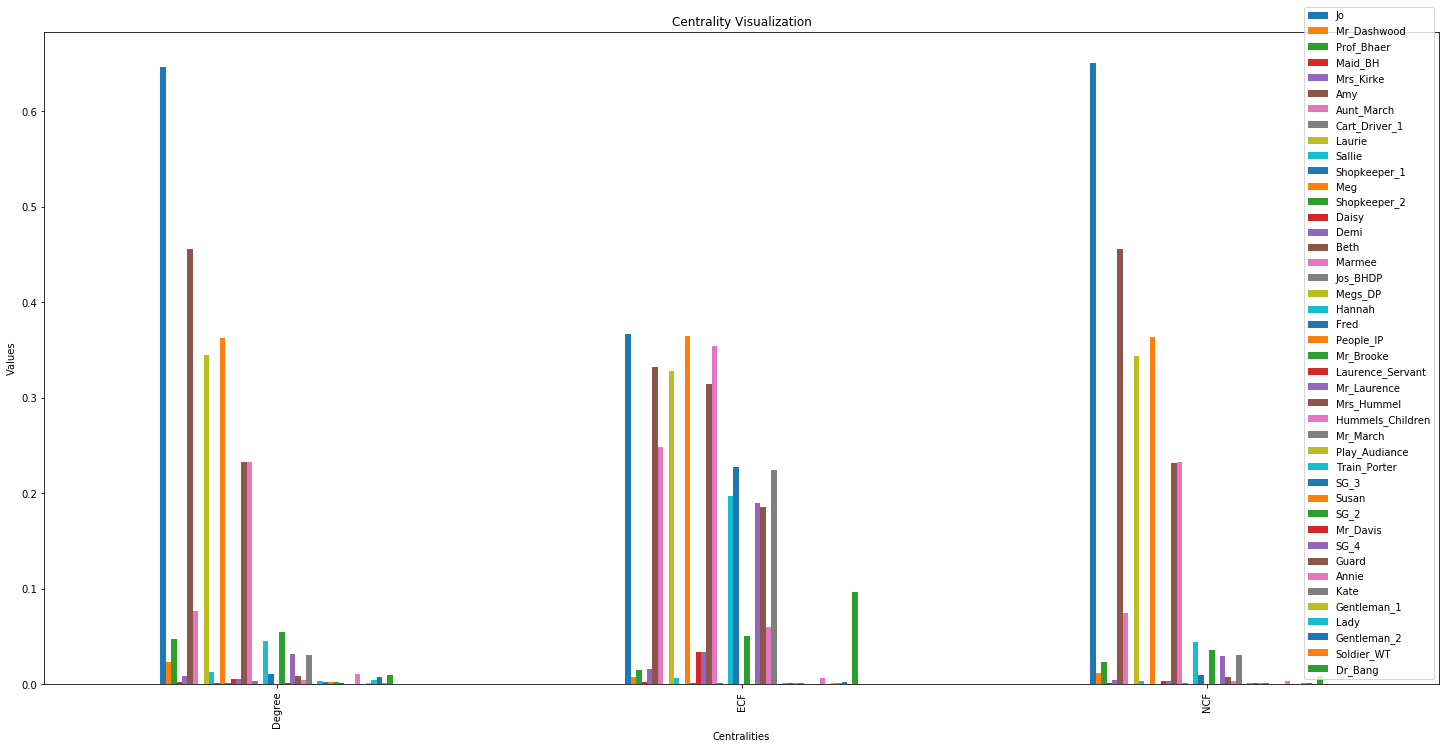

In [28]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),
    "Maid_BH":list(df_2.loc[3]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Cart_Driver_1":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Shopkeeper_1":list(df_2.loc[10]),
    "Meg":list(df_2.loc[11]),
    "Shopkeeper_2":list(df_2.loc[12]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Jos_BHDP":list(df_2.loc[17]),
    "Megs_DP":list(df_2.loc[18]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "People_IP":list(df_2.loc[21]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Laurence_Servant":list(df_2.loc[23]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mrs_Hummel":list(df_2.loc[25]),
    "Hummels_Children":list(df_2.loc[26]),
    "Mr_March":list(df_2.loc[27]),
    "Play_Audiance":list(df_2.loc[28]),
    "Train_Porter":list(df_2.loc[29]),
    "SG_3":list(df_2.loc[30]),
    "Susan":list(df_2.loc[31]),
    "SG_2":list(df_2.loc[32]),
    "Mr_Davis":list(df_2.loc[33]),
    "SG_4":list(df_2.loc[34]),
    "Guard":list(df_2.loc[35]),
    "Annie":list(df_2.loc[36]),
    "Kate":list(df_2.loc[37]),
    "Gentleman_1":list(df_2.loc[38]),
    "Lady":list(df_2.loc[39]),
    "Gentleman_2":list(df_2.loc[40]),
    "Soldier_WT":list(df_2.loc[41]),
    "Dr_Bang":list(df_2.loc[42])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

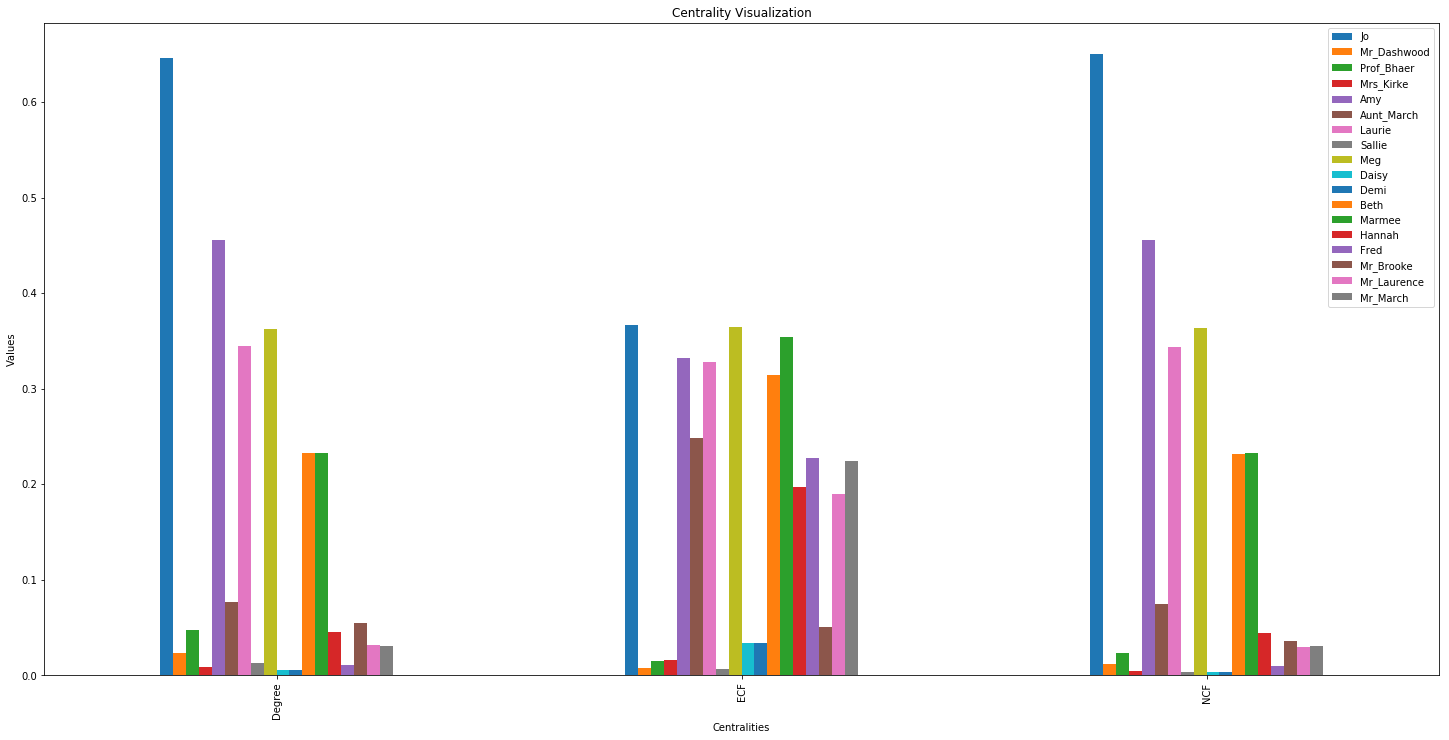

In [29]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Meg":list(df_2.loc[11]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mr_March":list(df_2.loc[27])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

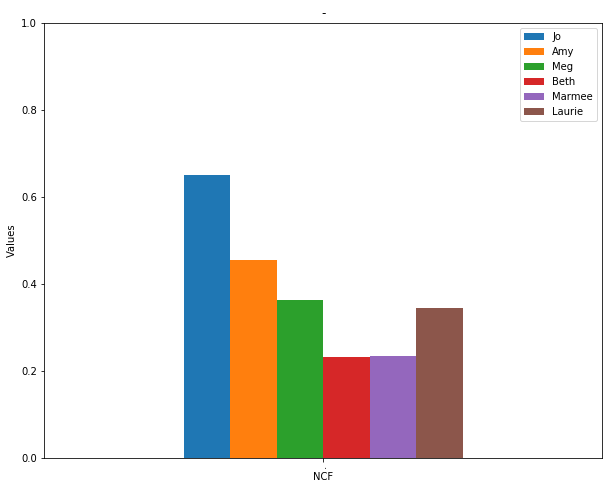

In [30]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[5][2],
    "Meg":df_2.loc[11][2],
    "Beth":df_2.loc[15][2],
    "Marmee":df_2.loc[16][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_8

Name: 
Type: Graph
Number of nodes: 43
Number of edges: 98
Average degree:   4.5581


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


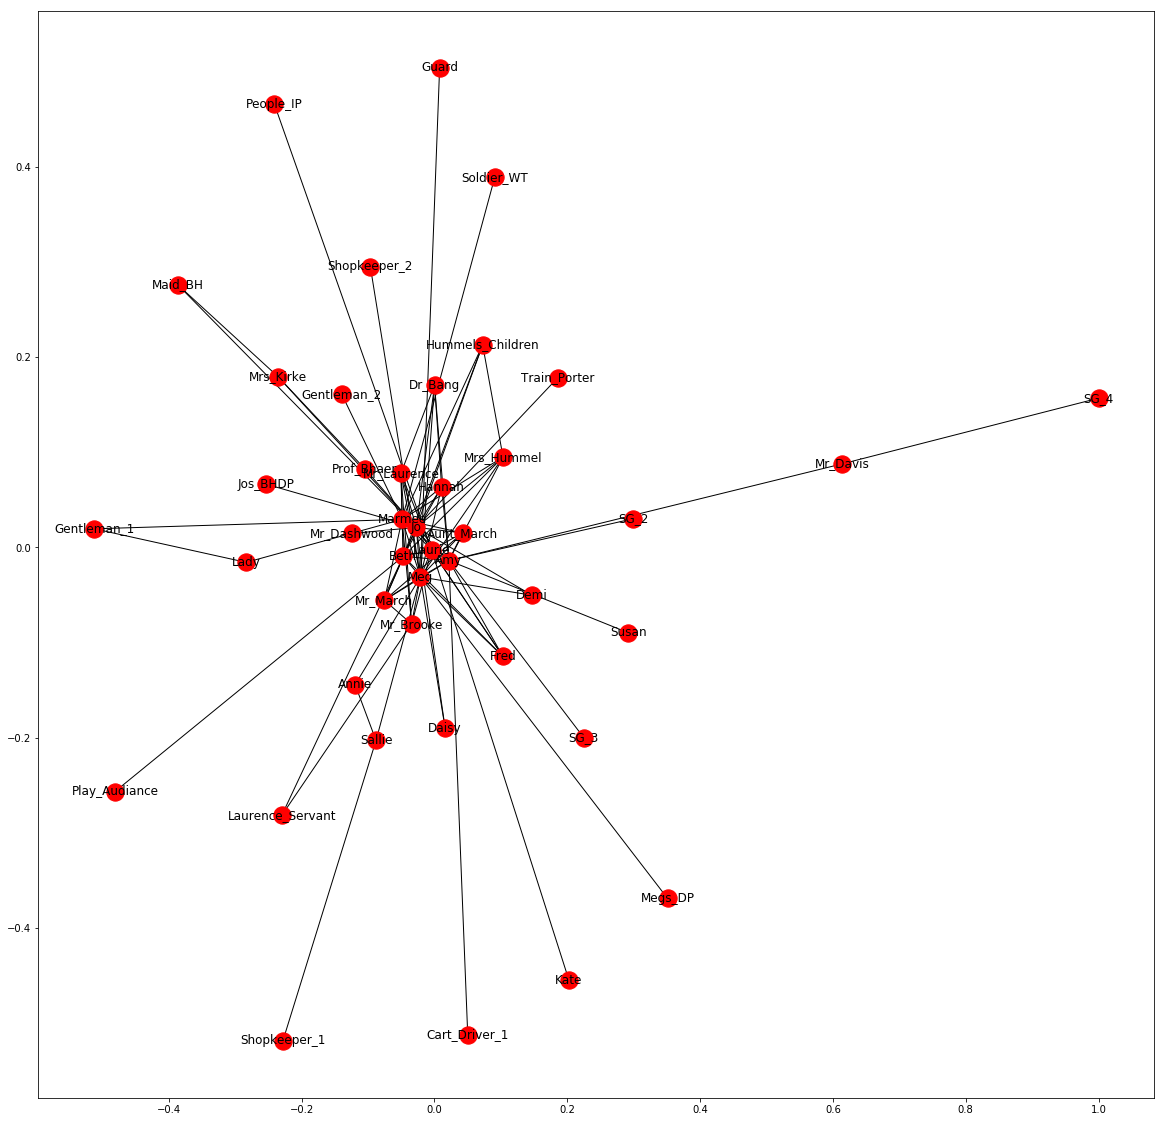

               Nodes  Degree       ECF           NCF
0                 Jo  1235.0  0.926153  2.521436e-01
1        Mr_Dashwood    40.0  0.020400  4.078303e-03
2         Prof_Bhaer    81.0  0.038352  8.339463e-03
3            Maid_BH     4.0  0.006936  4.118253e-04
4          Mrs_Kirke    15.0  0.039984  1.544345e-03
5                Amy   810.0  0.840065  1.636881e-01
6         Aunt_March   132.0  0.639739  2.613676e-02
7      Cart_Driver_1     1.0  0.000816  6.733361e-05
8             Laurie   648.0  0.832721  1.309505e-01
9             Sallie    22.0  0.016320  1.153577e-03
10      Shopkeeper_1     2.0  0.000816  3.662149e-06
11               Meg   627.0  0.920849  1.272807e-01
12      Shopkeeper_2     3.0  0.002040  1.560575e-04
13             Daisy    11.0  0.084455  1.525285e-03
14              Demi    11.0  0.084455  1.525285e-03
15              Beth   399.0  0.801306  8.076438e-02
16            Marmee   443.0  0.894329  8.970760e-02
17          Jos_BHDP     6.0  0.006528  6.1174

In [17]:
lw_8 = nx.read_weighted_edgelist('lw_m_8.txt', delimiter=',')
print(nx.info(lw_8))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_8)
plt.show()

#Weighted Centralities
w_deg = lw_8.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_8)  #ECF
w_ecf = weighted_ECF(lw_8, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_8) #NCF
w_ncf = weighted_cness(lw_8,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [18]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.670,0.365,0.674
1,0.022,0.008,0.011
2,0.044,0.015,0.022
3,0.002,0.003,0.001
4,0.008,0.016,0.004
5,0.439,0.331,0.438
6,0.072,0.252,0.070
7,0.001,0.000,0.000
8,0.351,0.329,0.350
9,0.012,0.006,0.003


Text(0, 0.5, 'Values')

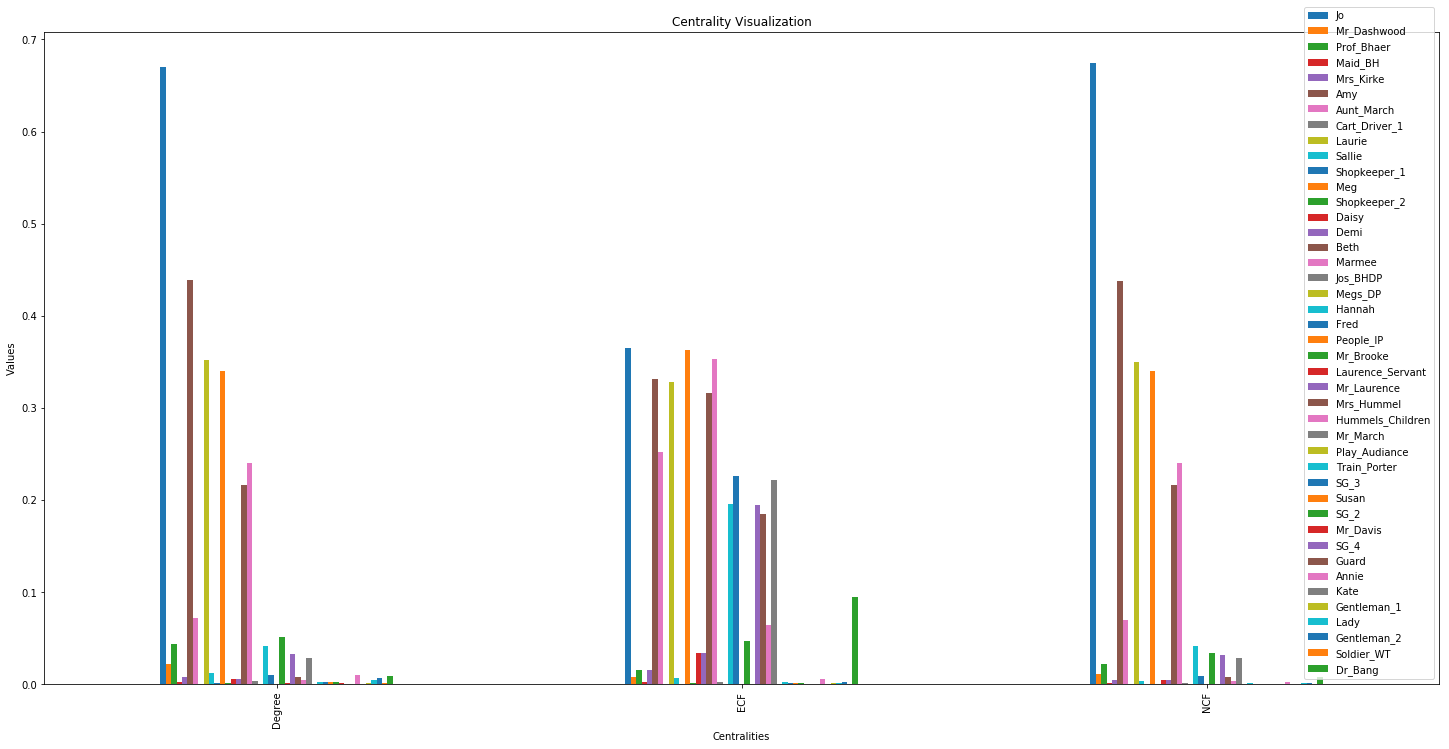

In [32]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),
    "Maid_BH":list(df_2.loc[3]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Cart_Driver_1":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Shopkeeper_1":list(df_2.loc[10]),
    "Meg":list(df_2.loc[11]),
    "Shopkeeper_2":list(df_2.loc[12]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Jos_BHDP":list(df_2.loc[17]),
    "Megs_DP":list(df_2.loc[18]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "People_IP":list(df_2.loc[21]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Laurence_Servant":list(df_2.loc[23]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mrs_Hummel":list(df_2.loc[25]),
    "Hummels_Children":list(df_2.loc[26]),
    "Mr_March":list(df_2.loc[27]),
    "Play_Audiance":list(df_2.loc[28]),
    "Train_Porter":list(df_2.loc[29]),
    "SG_3":list(df_2.loc[30]),
    "Susan":list(df_2.loc[31]),
    "SG_2":list(df_2.loc[32]),
    "Mr_Davis":list(df_2.loc[33]),
    "SG_4":list(df_2.loc[34]),
    "Guard":list(df_2.loc[35]),
    "Annie":list(df_2.loc[36]),
    "Kate":list(df_2.loc[37]),
    "Gentleman_1":list(df_2.loc[38]),
    "Lady":list(df_2.loc[39]),
    "Gentleman_2":list(df_2.loc[40]),
    "Soldier_WT":list(df_2.loc[41]),
    "Dr_Bang":list(df_2.loc[42])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

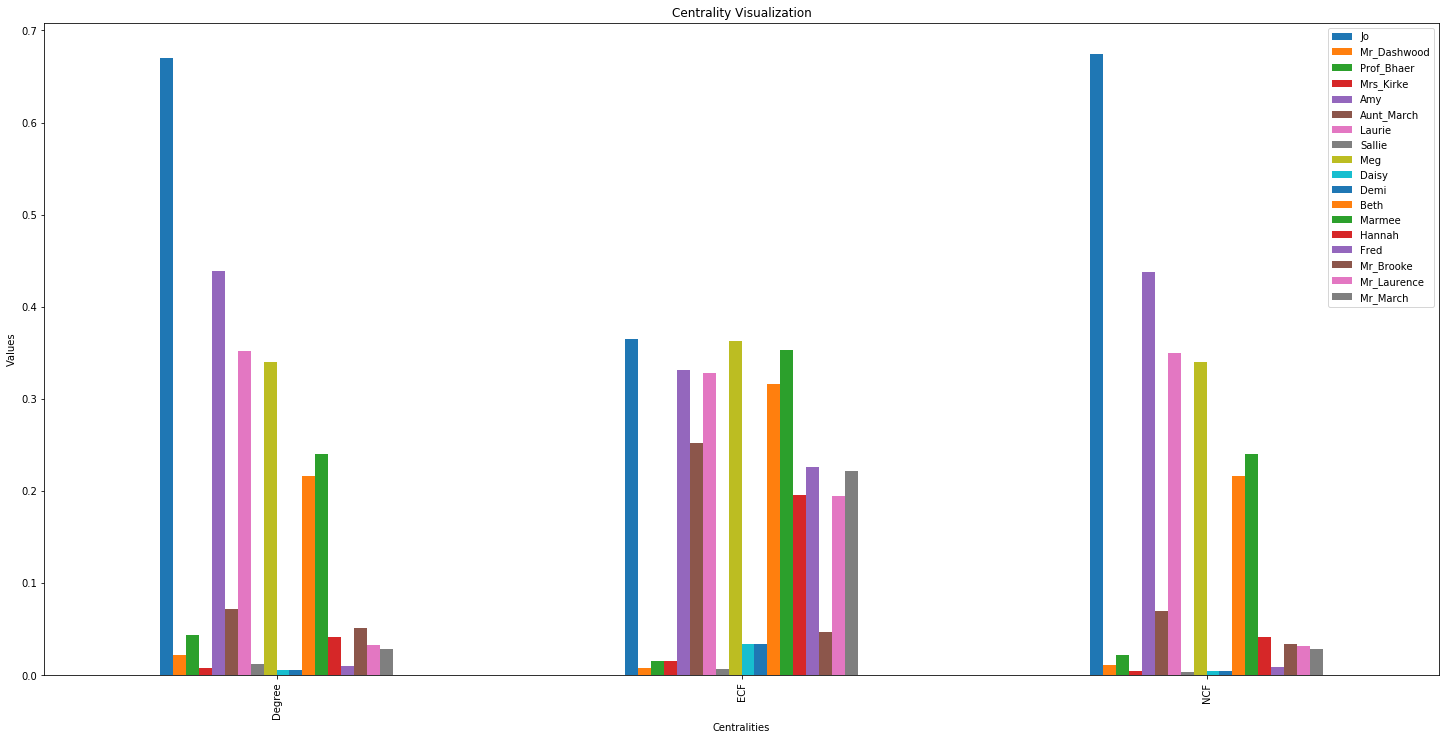

In [33]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Meg":list(df_2.loc[11]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mr_March":list(df_2.loc[27])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

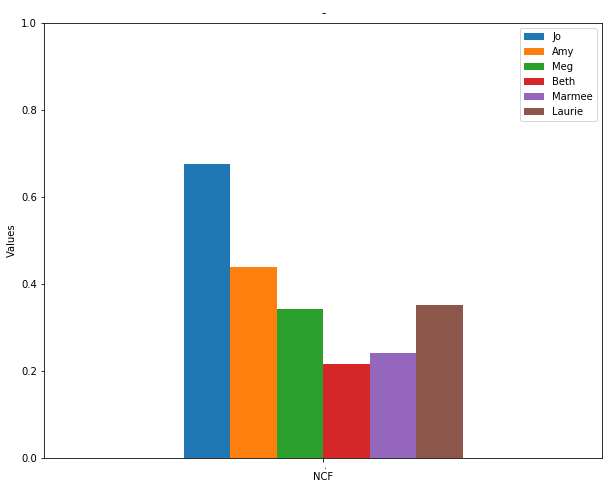

In [34]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[5][2],
    "Meg":df_2.loc[11][2],
    "Beth":df_2.loc[15][2],
    "Marmee":df_2.loc[16][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

### lw_n_9

Name: 
Type: Graph
Number of nodes: 48
Number of edges: 113
Average degree:   4.7083


C:\ProgramData\Anaconda3\lib\site-packages\networkx\drawing\nx_pylab.py:611: MatplotlibDeprecationWarning: isinstance(..., numbers.Number)
  if cb.is_numlike(alpha):


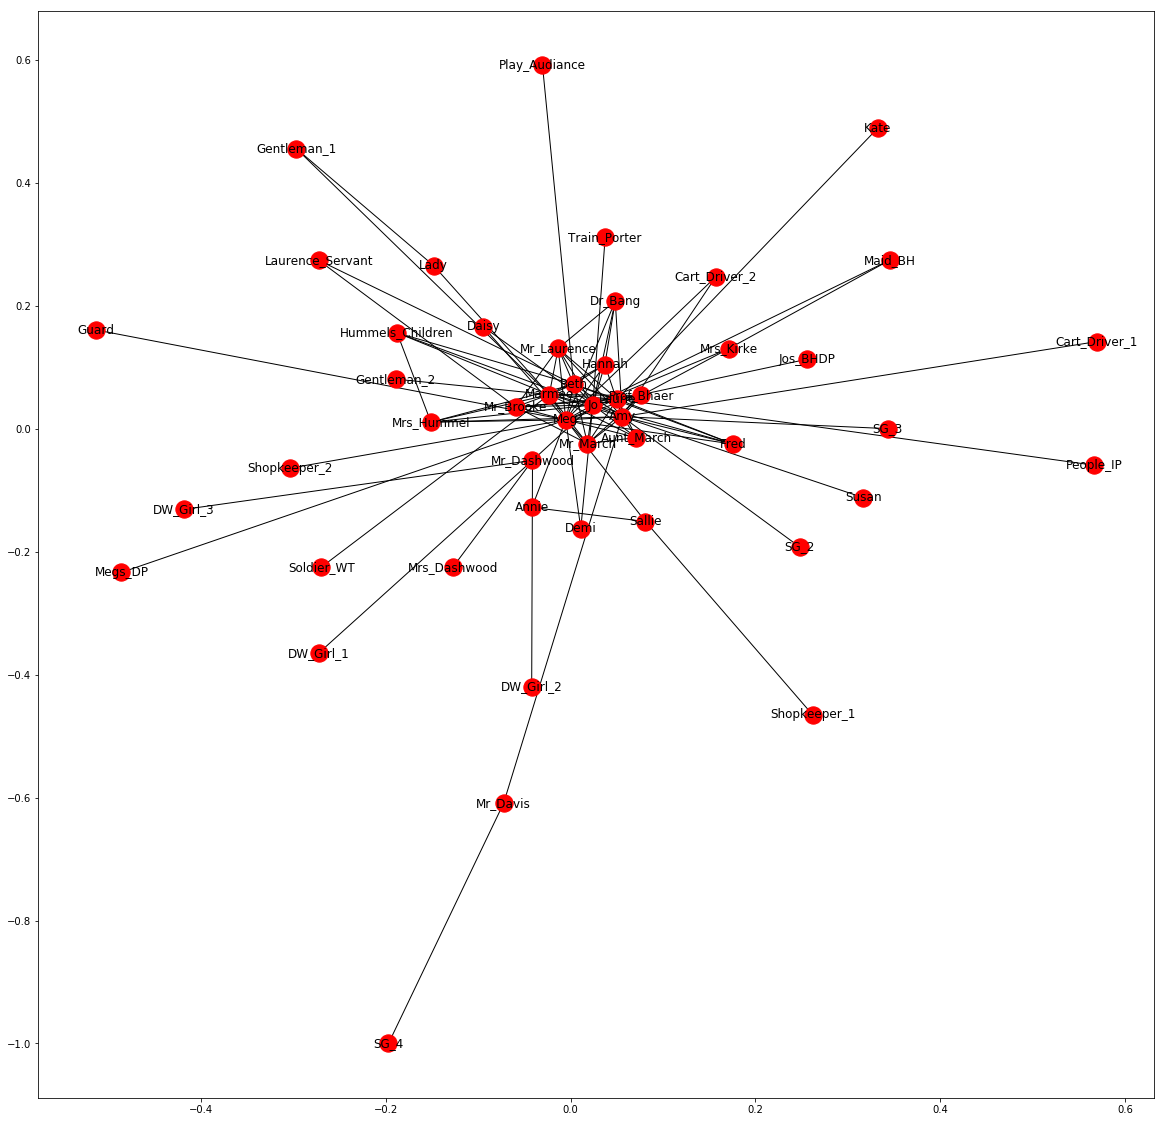

               Nodes  Degree       ECF           NCF
0                 Jo  1464.0  0.961288  2.651210e-01
1        Mr_Dashwood   131.0  0.051013  1.258610e-02
2         Prof_Bhaer   157.0  0.657019  2.770215e-02
3            Maid_BH     4.0  0.009407  3.837849e-04
4          Mrs_Kirke    24.0  0.051013  2.368681e-03
5                Amy   882.0  0.866860  1.582237e-01
6         Aunt_March   132.0  0.610709  2.312684e-02
7      Cart_Driver_1     1.0  0.000724  5.765936e-05
8             Laurie   671.0  0.857453  1.201524e-01
9             Sallie    22.0  0.014472  9.877356e-04
10      Shopkeeper_1     2.0  0.000724  2.879696e-06
11               Meg   683.0  0.919682  1.227929e-01
12      Shopkeeper_2     3.0  0.001809  1.337095e-04
13             Daisy    11.0  0.087916  1.378654e-03
14              Demi    11.0  0.087916  1.378654e-03
15              Beth   399.0  0.757236  7.129014e-02
16            Marmee   461.0  0.894356  8.269969e-02
17          Jos_BHDP     6.0  0.005789  5.7096

In [19]:
lw_9 = nx.read_weighted_edgelist('lw_m_9.txt', delimiter=',')
print(nx.info(lw_9))

plt.figure(figsize = (20,20))
nx.draw_networkx(lw_9)
plt.show()

#Weighted Centralities
w_deg = lw_9.degree(weight='weight') # Degree
w_deg = list(w_deg)

total_edge_weight = total_weight_of_G(lw_9)  #ECF
w_ecf = weighted_ECF(lw_9, total_edge_weight)

total_edge_weight = total_weight_of_G(lw_9) #NCF
w_ncf = weighted_cness(lw_9,total_edge_weight)


df = pd.DataFrame()
df["Nodes"] = convert_to_list_value(w_deg,0)
df["Degree"] = convert_to_list_value(w_deg,1)
df["ECF"] = convert_to_list_value(w_ecf,1)
df["NCF"] = convert_to_list_value(w_ncf,1)

print(df)

degree_c = np.array(df['Degree'])
ecf_c = np.array(df['ECF'])
ncf_c = np.array(df['NCF'])

normalized_deg = preprocessing.normalize([degree_c])

normalized_ecf = preprocessing.normalize([ecf_c])

normalized_ncf = preprocessing.normalize([ncf_c])

df_2 = pd.DataFrame()
df_2["Degree"] = np.concatenate(normalized_deg).ravel()
df_2["ECF"] = np.concatenate(normalized_ecf).ravel()
df_2["NCF"] = np.concatenate(normalized_ncf).ravel()

print(df_2)

In [20]:
df_3 = df_2
df_3.round(decimals = 3)

,Degree,ECF,NCF
0,0.706,0.347,0.711
1,0.063,0.018,0.034
2,0.076,0.237,0.074
3,0.002,0.003,0.001
4,0.012,0.018,0.006
5,0.425,0.313,0.424
6,0.064,0.221,0.062
7,0.000,0.000,0.000
8,0.324,0.310,0.322
9,0.011,0.005,0.003


Text(0, 0.5, 'Values')

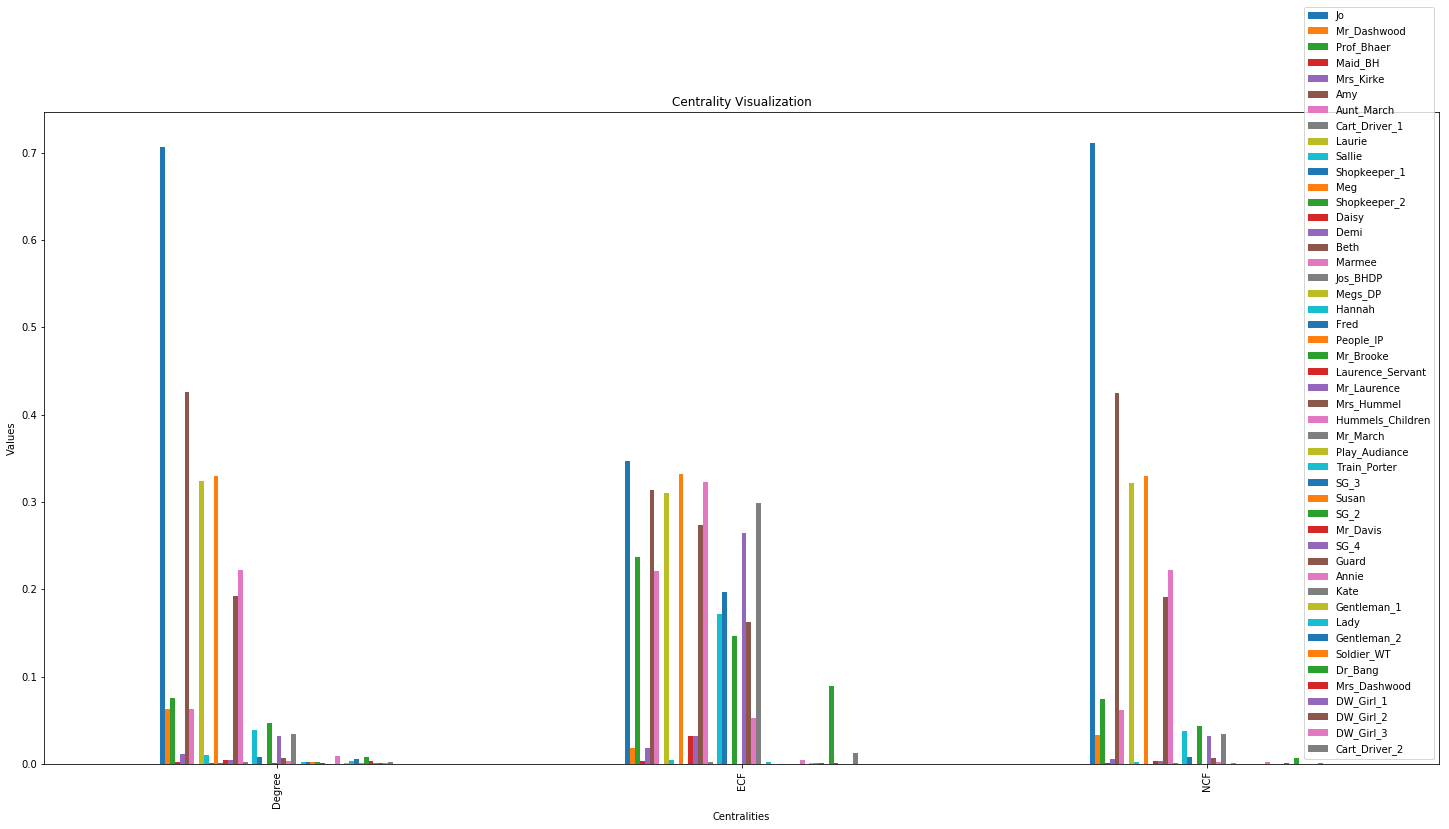

In [36]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),
    "Maid_BH":list(df_2.loc[3]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Cart_Driver_1":list(df_2.loc[7]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Shopkeeper_1":list(df_2.loc[10]),
    "Meg":list(df_2.loc[11]),
    "Shopkeeper_2":list(df_2.loc[12]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Jos_BHDP":list(df_2.loc[17]),
    "Megs_DP":list(df_2.loc[18]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "People_IP":list(df_2.loc[21]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Laurence_Servant":list(df_2.loc[23]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mrs_Hummel":list(df_2.loc[25]),
    "Hummels_Children":list(df_2.loc[26]),
    "Mr_March":list(df_2.loc[27]),
    "Play_Audiance":list(df_2.loc[28]),
    "Train_Porter":list(df_2.loc[29]),
    "SG_3":list(df_2.loc[30]),
    "Susan":list(df_2.loc[31]),
    "SG_2":list(df_2.loc[32]),
    "Mr_Davis":list(df_2.loc[33]),
    "SG_4":list(df_2.loc[34]),
    "Guard":list(df_2.loc[35]),
    "Annie":list(df_2.loc[36]),
    "Kate":list(df_2.loc[37]),
    "Gentleman_1":list(df_2.loc[38]),
    "Lady":list(df_2.loc[39]),
    "Gentleman_2":list(df_2.loc[40]),
    "Soldier_WT":list(df_2.loc[41]),
    "Dr_Bang":list(df_2.loc[42]),
    "Mrs_Dashwood":list(df_2.loc[43]),
    "DW_Girl_1":list(df_2.loc[44]),
    "DW_Girl_2":list(df_2.loc[45]),
    "DW_Girl_3":list(df_2.loc[46]),
    "Cart_Driver_2":list(df_2.loc[47])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

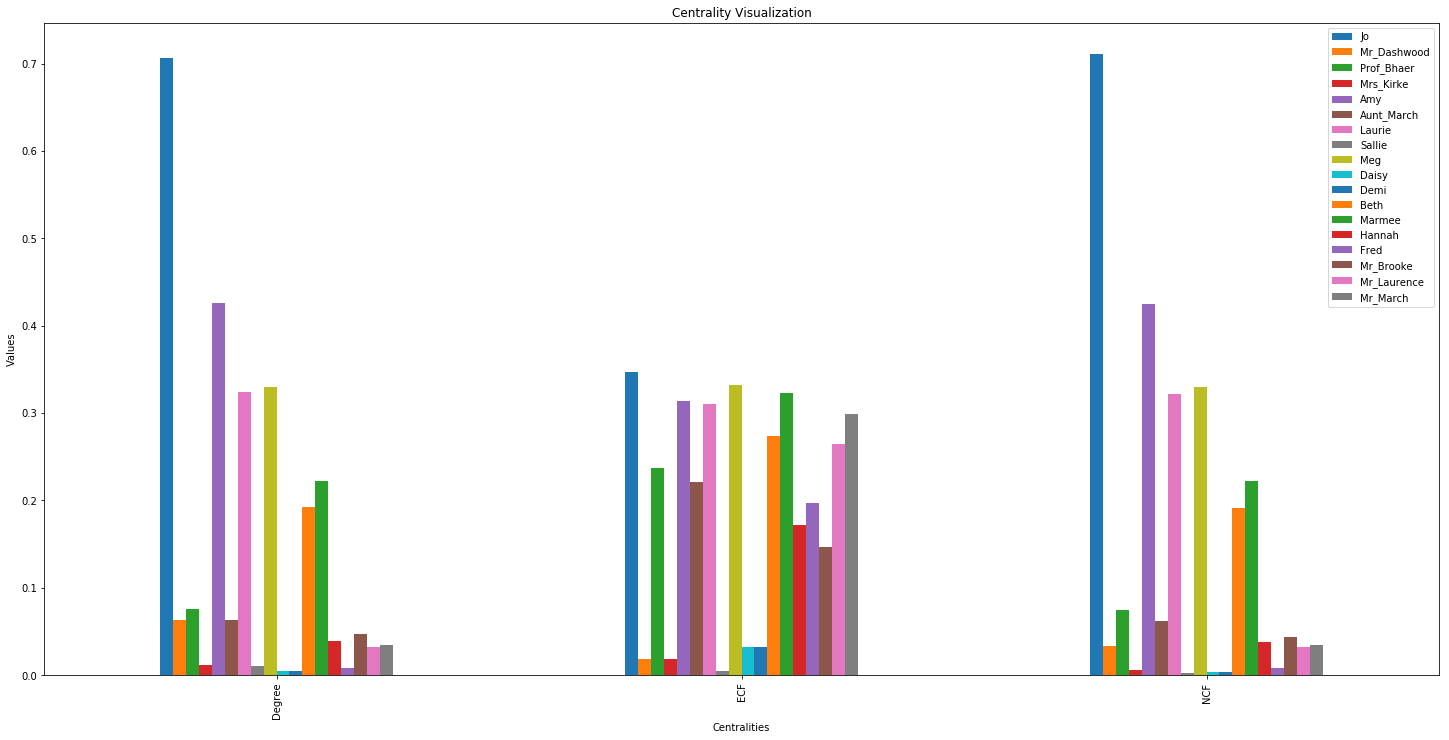

In [37]:
plotdata = pd.DataFrame({

    "Jo":list(df_2.loc[0]),
    "Mr_Dashwood":list(df_2.loc[1]),
    "Prof_Bhaer":list(df_2.loc[2]),    
    "Mrs_Kirke":list(df_2.loc[4]),
    "Amy":list(df_2.loc[5]),
    "Aunt_March":list(df_2.loc[6]),
    "Laurie":list(df_2.loc[8]),
    "Sallie":list(df_2.loc[9]),
    "Meg":list(df_2.loc[11]),
    "Daisy":list(df_2.loc[13]),
    "Demi":list(df_2.loc[14]),
    "Beth":list(df_2.loc[15]),
    "Marmee":list(df_2.loc[16]),
    "Hannah":list(df_2.loc[19]),
    "Fred":list(df_2.loc[20]),
    "Mr_Brooke":list(df_2.loc[22]),
    "Mr_Laurence":list(df_2.loc[24]),
    "Mr_March":list(df_2.loc[27])},

    index=["Degree", "ECF", "NCF"])

plotdata.plot(kind="bar",figsize=(25, 12))

plt.title("Centrality Visualization")

plt.xlabel("Centralities")

plt.ylabel("Values")

Text(0, 0.5, 'Values')

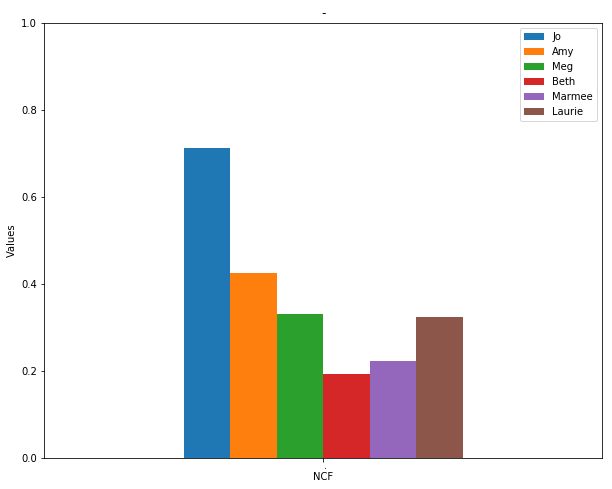

In [38]:
plotdata = pd.DataFrame({

    "Jo":df_2.loc[0][2],
    "Amy":df_2.loc[5][2],
    "Meg":df_2.loc[11][2],
    "Beth":df_2.loc[15][2],
    "Marmee":df_2.loc[16][2],
    "Laurie":df_2.loc[8][2]},

    index=["."])

plotdata.plot(kind="bar",figsize=(10, 8), ylim=[0,1])

plt.title("-")

plt.xlabel("NCF")

plt.ylabel("Values")

In [39]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4', 't5', 't6', 't7', 't8', 't9']

jo = [0.676284,0.684663,0.681373,0.702546,6.466428e-01,6.249348e-01,6.503526e-01,6.744951e-01,7.110398e-01]
amy = [0.392649,0.455266,0.459933,0.459795,4.686150e-01,4.865275e-01,4.551681e-01,4.378728e-01,4.243472e-01]
meg = [0.353240,0.314276,0.338024,0.332610,3.786550e-01,3.655720e-01,3.634289e-01,3.404816e-01,3.293238e-01]
beth = [0.102497,0.218774,0.213330,0.189215,1.931690e-01,2.369861e-01,2.320516e-01,2.160482e-01,1.911962e-01]
marmee = [0.158646,0.314391,0.237677,0.239301,2.210108e-01,2.418482e-01,2.327343e-01,2.399717e-01,2.217960e-01]
laurie = [0.464040,0.261178,0.309761,0.287651,3.538792e-01,3.419207e-01,3.436983e-01,3.502983e-01,3.222421e-01]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Jo' : jo,'Amy' : amy, 'Meg' : meg, 'Beth' : beth, 'Marmee' : marmee, 'Laurie' : laurie})
df_pop_density

,Timestamp,Jo,Amy,Meg,Beth,Marmee,Laurie
0,t1,0.676284,0.392649,0.353240,0.102497,0.158646,0.464040
1,t2,0.684663,0.455266,0.314276,0.218774,0.314391,0.261178
2,t3,0.681373,0.459933,0.338024,0.213330,0.237677,0.309761
3,t4,0.702546,0.459795,0.332610,0.189215,0.239301,0.287651
4,t5,0.646643,0.468615,0.378655,0.193169,0.221011,0.353879
5,t6,0.624935,0.486528,0.365572,0.236986,0.241848,0.341921
6,t7,0.650353,0.455168,0.363429,0.232052,0.232734,0.343698
7,t8,0.674495,0.437873,0.340482,0.216048,0.239972,0.350298
8,t9,0.711040,0.424347,0.329324,0.191196,0.221796,0.322242


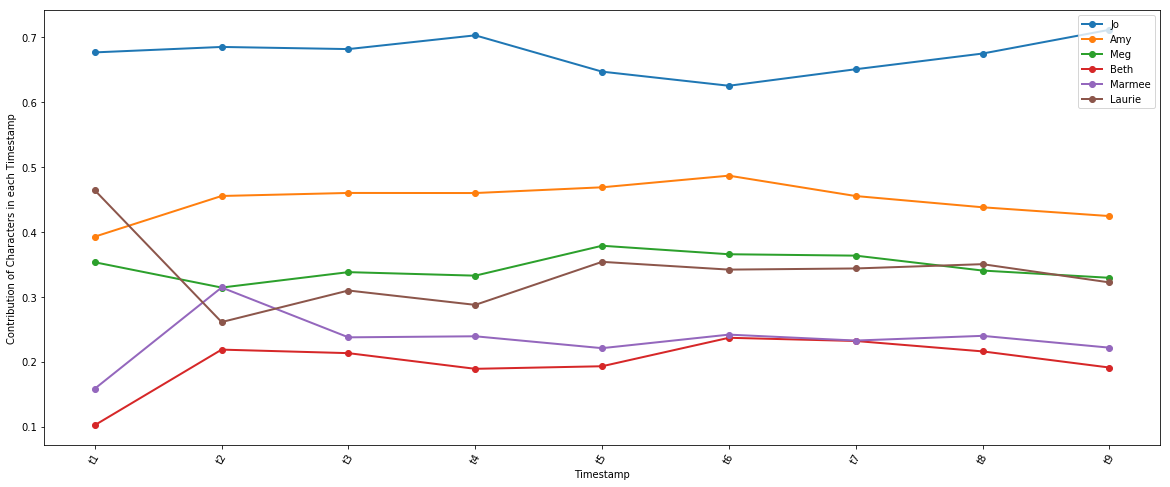

In [40]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[20, 8])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Jo'], marker='o', linewidth=2, label='Jo')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Amy'], marker='o', linewidth=2, label='Amy')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Meg'], marker='o', linewidth=2, label='Meg')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Beth'], marker='o', linewidth=2, label='Beth')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Marmee'], marker='o', linewidth=2, label='Marmee')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Laurie'], marker='o', linewidth=2, label='Laurie')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Contribution of Characters in each Timestamp')
plt.legend()
plt.show()

In [12]:
# Reevaluate the remaining part

In [62]:
# Let's create a Dataframe using lists
timestamp = ['t1', 't2', 't3', 't4']

apoorva_yogmaya = [0.8181818181818182,1.4729064039408866,1.6794258373205742,1.3652450090744102]

apoorva_mrinmoyee = [0.5454545454545454,1.379310344827586,2.0050125313283207,1.4123376623376624]

# Now, create a pandas dataframe using above lists
df_pop_density = pd.DataFrame(
    {'Timestamp' : timestamp, 'Correlation_With_Yogmaya' : apoorva_yogmaya, 'Correlation_With_Mrinmoyee' : apoorva_mrinmoyee})

df_pop_density

,Timestamp,Correlation_With_Yogmaya,Correlation_With_Mrinmoyee
0,t1,0.818182,0.545455
1,t2,1.472906,1.379310
2,t3,1.679426,2.005013
3,t4,1.365245,1.412338


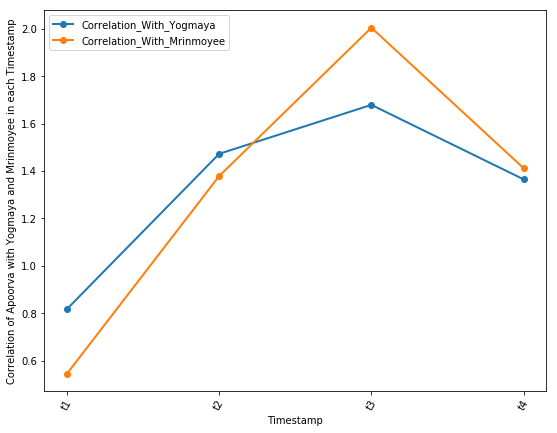

In [63]:
# Creating figure and axis objects using subplots()
fig, ax = plt.subplots(figsize=[9, 7])

ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Yogmaya'], marker='o', linewidth=2, label='Correlation_With_Yogmaya')
ax.plot(df_pop_density['Timestamp'], df_pop_density['Correlation_With_Mrinmoyee'], marker='o', linewidth=2, label='Correlation_With_Mrinmoyee')
plt.xticks(rotation=60)
ax.set_xlabel('Timestamp')
ax.set_ylabel('Correlation of Apoorva with Yogmaya and Mrinmoyee in each Timestamp')
plt.legend()
plt.show()